# t2i v6.0 · 判分结果审阅（三消融 → case 逐项）

数据：`eval_score.py score --v60 {V2,V5} --model <判官> --source <图源>` 产出的 `scores_t2i_v60_*.jsonl`。
当前覆盖：gpt-5.6-sol（V2/V5 全 40）、claude-opus-5（V2 双图源 20）、gemini-2.5-pro（V2 partial，已取消）。

- **Cell 1** 数据加载与总览：三消融汇总表 + 覆盖面
- **Cell 2** 消融① 判官（V2 两两）：一致率热力图 / 逐项均档散点（中文）/ 最大分歧 case（图+证据）
- **Cell 3** 消融② 条件 V2 vs V5（仅 gpt-5.6-sol 有配对）：线级差分 / 逐项对比与迁移 / 翻转证据下钻
- **Cell 4** 消融③ 图源 bagel vs gpt-image-2：三线 / 22 项明细 / 零档频次 / 难度剖面 / 热力表
- **Cell 5** case 逐项对比：题面+图+全组合打分矩阵、V2/V5 哑铃卡、reasons 查阅

In [1]:
# ---- v6.0 判分结果 · 数据加载与三消融总览 ----
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# cwd 自适应：仓库根或 benchmark/t2i/ 启动均可
# cwd 自适应：从 t2i/ 或 reviews/ 启动均可（2026-09-05 重组布局）
T2I = Path.cwd() if (Path.cwd() / 'bench200').exists() else Path.cwd().parent
EVAL_DIR = T2I / 'data'
ARCHIVE = T2I / 'archive' / 'v60_ladder'
V5LINE = T2I / 'archive' / 'v5_line'
V1BENCH = T2I / 'bench200'
R10_SYNTH = T2I / 'bench200' / 'provenance' / 'r10_synth'
assert EVAL_DIR.exists() and ARCHIVE.exists(), f'路径解析失败（当前 {cwd}）'.format(cwd=Path.cwd())
PHI = {0: 0.0, 1: 60.0, 2: 100.0}   # 0→0 / 1→60 / 2→100，N/A 剔除
COND_JUDGE = 'openrouter/openai/gpt-5.6-sol'   # V2/V5 消融只用该判官（唯一有 V5 配对）
plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ITEM_ZH = {'subject_presence': '主体在场', 'form_structure': '形态结构',
           'color_material': '颜色材质', 'quantity_scale': '数量尺度',
           'spatial_relation': '空间关系', 'text_symbol': '文字符号',
           'action_interaction': '动作交互', 'state_context': '状态情境',
           'scene_environment': '场景环境', 'style': '风格',
           'physical_logic': '物理逻辑', 'material_texture': '材质质感',
           'detail_richness': '细节丰富', 'artifacts': '伪影', 'resolution': '分辨率',
           'edge_clarity': '边缘清晰', 'naturalness': '自然度',
           'anatomical_fidelity': '解剖保真', 'composition': '构图',
           'color_harmony': '色彩和谐', 'lighting_atmosphere': '光影氛围',
           'emotional_expression': '情绪传达'}
DIM_ZH = {'alignment': '对齐', 'quality': '质量', 'aesthetics': '美感'}
def _zh(t):
    """(dim, item) 多级索引 → (中文维度, 中文项名)"""
    return (DIM_ZH.get(t[0], t[0]), ITEM_ZH.get(t[1], t[1]))
RK = {'alignment': ('alignment_scores', 'alignment_reasons'),
      'quality': ('quality_scores', 'quality_reasons'),
      'aesthetics': ('aesthetic_scores', 'aesthetic_reasons')}
IMG_OF = {'gpt-image-2': lambda q: ARCHIVE / 'eval_v60_r6' / 'imgs' / 'gpt-image-2' / f'{q}.png',
          'bagel': lambda q: ARCHIVE / 'eval_v60_r6' / 'bagel' / 'imgs' / f'{q}.png'}
QS = {q['qid']: q for q in
      (json.loads(l) for l in
       (ARCHIVE / 'synth_gen_v60_r6' / 'questions_v60_gpt-5.6-sol.jsonl')
       .read_text(encoding='utf-8').splitlines() if l.strip())}

rows, fails = [], []
for fp in sorted(list(EVAL_DIR.glob('scores_t2i_v60_*.jsonl')) + list(ARCHIVE.glob('ablation_scores/scores_t2i_v60_*.jsonl'))):
    for line in fp.read_text(encoding='utf-8').splitlines():
        if line.strip():
            (fails if json.loads(line).get('fail') else rows).append(json.loads(line))
df = pd.DataFrame(rows)
assert rows, f'尚无消融分数（{EVAL_DIR} 或 {ARCHIVE}/ablation_scores）'
print(f'判分 {len(rows)} 行（fail {len(fails)} 行已剔除）；覆盖组合（判官 × 条件 × 图源）：')
print(df.groupby(['judge_model', 'schema', 'image_model']).size().rename('n').to_string())

print('\n① 三消融总览：判官 × 条件 × 图源 → 三线分均值')
display(df.groupby(['judge_model', 'schema', 'image_model'])
          .agg(n=('qid', 'size'), align=('alignment_score', 'mean'),
               quality=('quality_score', 'mean'), aesthetic=('aesthetic_score', 'mean'))
          .round(1))

判分 52 行（fail 4 行已剔除）；覆盖组合（判官 × 条件 × 图源）：
judge_model                         schema   image_model
openrouter/anthropic/claude-opus-5  v6.0-V2  bagel          10
                                             gpt-image-2    10
openrouter/google/gemini-2.5-pro    v6.0-V2  bagel           4
                                             gpt-image-2     8
openrouter/openai/gpt-5.6-sol       v6.0-V2  bagel          10
                                             gpt-image-2    10

① 三消融总览：判官 × 条件 × 图源 → 三线分均值


n  align  quality  \
judge_model                        schema  image_model                       
openrouter/anthropic/claude-opus-5 v6.0-V2 bagel        10   35.0     53.0   
                                           gpt-image-2  10   60.1     61.6   
openrouter/google/gemini-2.5-pro   v6.0-V2 bagel         4   46.8     58.1   
                                           gpt-image-2   8   74.4     67.7   
openrouter/openai/gpt-5.6-sol      v6.0-V2 bagel        10   27.7     43.3   
                                           gpt-image-2  10   71.1     70.9   

                                                        aesthetic  
judge_model                        schema  image_model             
openrouter/anthropic/claude-opus-5 v6.0-V2 bagel             60.0  
                                           gpt-image-2       60.0  
openrouter/google/gemini-2.5-pro   v6.0-V2 bagel             70.8  
                                           gpt-image-2       76.7  
openrouter/openai/gpt-5.6-sol      v6.0-V2 bagel             61.0  
                                           gpt-image-2       71.3

In [2]:
# ---- 消融① 判官（V2 口径两两比较；V5 仅 gpt-5.6-sol 有，不进本节）----
import numpy as np
from PIL import Image
from itertools import combinations

items = pd.DataFrame([
    {'qid': r['qid'], 'schema': r['schema'], 'image_model': r['image_model'],
     'judge': r['judge_model'], 'dim': d, 'item': k, 'score': v}
    for r in rows
    for d, (sk, _) in RK.items()
    for k, v in r[sk].items() if v in (0, 1, 2)])
piv = items.pivot_table(index=['qid', 'schema', 'image_model', 'dim', 'item'],
                        columns='judge', values='score').dropna()
JS = sorted(piv.columns)

if len(JS) >= 2:
    print('各判官 V2 三线均分（全局印象：谁整体更严/更松）：')
    display(df[df['schema'] == 'v6.0-V2']
            .groupby('judge_model')[['alignment_score', 'quality_score', 'aesthetic_score']]
            .mean().round(1).rename(columns={'alignment_score': '对齐', 'quality_score': '质量',
                                             'aesthetic_score': '美感'}))
    ag_rows = []
    for ja, jb in combinations(JS, 2):
        sub = piv[[ja, jb]].dropna()
        if not len(sub):
            continue
        same = sub[ja] == sub[jb]
        per_dim = same.groupby(sub.index.get_level_values('dim')).mean()
        ag_rows.append({'配对': f"{ja.split('/')[-1]} vs {jb.split('/')[-1]}",
                        '整体': float(same.mean()),
                        **{d: float(per_dim[d]) if d in per_dim.index else float('nan')
                           for d in ('alignment', 'quality', 'aesthetics')}})
    ag = pd.DataFrame(ag_rows).set_index('配对')
    jm = items.pivot_table(index=['dim', 'item'], columns='judge', values='score',
                           aggfunc='mean')[JS]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 9),
                                   gridspec_kw={'width_ratios': [1, 1.7]})
    im_ = ax1.imshow(ag.values, vmin=0.5, vmax=1.0, cmap='RdYlGn', aspect='auto')
    ax1.set_xticks(range(ag.shape[1]))
    ax1.set_xticklabels(['整体', '对齐', '质量', '美感'], fontsize=9)
    ax1.set_yticks(range(ag.shape[0]))
    ax1.set_yticklabels(ag.index, fontsize=8.5)
    for i in range(ag.shape[0]):
        for j in range(ag.shape[1]):
            ax1.text(j, i, f'{ag.values[i, j]:.0%}', ha='center', va='center', fontsize=9)
    ax1.set_title('两两一致率（同题·同项·同条件·同图源，N/A 剔除）', fontsize=10)
    fig.colorbar(im_, ax=ax1, fraction=0.04, pad=0.02)

    ys = np.arange(len(jm))[::-1]
    for jj, c in enumerate(jm.columns):
        ax2.scatter(jm[c].values, ys, s=44, color=plt.cm.tab10(jj), zorder=3,
                    label=c.split('/')[-1])
    ax2.set_yticks(ys)
    ax2.set_yticklabels([ITEM_ZH.get(k, k) for _, k in jm.index], fontsize=8.5)
    dims = jm.index.get_level_values(0)
    n_a = (dims == 'alignment').sum()
    ax2.axhline(n_a - 0.5, color='k', lw=0.7)
    ax2.axhline(n_a + (dims == 'quality').sum() - 0.5, color='k', lw=0.7)
    ax2.set_xlim(-0.15, 2.3)
    ax2.set_xticks([0, 1, 2])
    ax2.set_xticklabels(['0\nFail', '1\nPass', '2\nExcel'], fontsize=9)
    ax2.grid(axis='x', lw=0.4, alpha=0.4)
    ax2.set_title('各判官逐项均档（同一行点拉得越开 = 判官分歧越大）', fontsize=10)
    ax2.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()

    N_SPLIT = 6   # 展示的最大分歧 case 数
    spread = piv.apply(lambda r: r.max() - r.min() if r.notna().sum() >= 2 else np.nan,
                       axis=1).dropna()
    top = spread[spread >= 1].sort_values(ascending=False).head(N_SPLIT)
    print(f'\n最大分歧 TOP{N_SPLIT}（同题同项判官档位极差 ≥1；附图 + 各方档位与证据）：')
    thumbs = []
    for (qid, schema, src, d, k), sp in top.items():
        print(f'--- [{qid}·{schema[-2:]}·{src}] {ITEM_ZH.get(k, k)}（极差 {int(sp)} 档）')
        for r in rows:
            if r['qid'] == qid and r['schema'] == schema and r['image_model'] == src:
                sk, rk = RK[d]
                print(f"    {r['judge_model'].split('/')[-1]:>16}: {r[sk][k]}  | "
                      f"{str(r[rk].get(k, ''))[:64]}")
        p = IMG_OF.get(src, lambda q: None)(qid)
        if p and Path(p).exists():
            thumbs.append((f'{qid}·{src}·{ITEM_ZH.get(k, k)}', p))
    if thumbs:
        fig, axs = plt.subplots(1, len(thumbs), figsize=(3.4 * len(thumbs), 3.6),
                                squeeze=False)
        for ax, (t, p) in zip(axs[0], thumbs):
            ax.imshow(Image.open(p))
            ax.set_title(t, fontsize=8)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print(f'判官数 {len(JS)}（<2），跳过判官消融')

各判官 V2 三线均分（全局印象：谁整体更严/更松）：


,对齐,质量,美感
judge_model,,,
openrouter/anthropic/claude-opus-5,47.6,57.3,60.0
openrouter/google/gemini-2.5-pro,65.2,64.5,74.7
openrouter/openai/gpt-5.6-sol,49.4,57.1,66.2


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


/tmp/ipykernel_47952/1058953334.py:66: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47952/1058953334.py:66: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  plt.tight_layout()
findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


/tmp/ipykernel_47952/1058953334.py:92: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47952/1058953334.py:92: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_47952/1058953334.py:92: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from current font.
  plt.tight_layout()


<Figure size 2040x360 with 6 Axes>

In [3]:
# ---- 消融② 条件 V2 vs V5（判官 = COND_JUDGE，唯一有 V5 配对；其余判官自动剔除）----
df_c = df if COND_JUDGE is None else df[df['judge_model'] == COND_JUDGE]
items_c = items if COND_JUDGE is None else items[items['judge'] == COND_JUDGE]
print(f'判官 = {(COND_JUDGE or "有配对全用").split("/")[-1]}')

# ① 线级差分
lv = df_c.pivot_table(index=['qid', 'judge_model', 'image_model'], columns='schema',
                      values='alignment_score').dropna()
if {'v6.0-V2', 'v6.0-V5'} <= set(lv.columns):
    lv['V5-V2'] = lv['v6.0-V5'] - lv['v6.0-V2']
    print('V5−V2 对齐线差分（正 = 出题思路让判官更严；逐题配对差）：')
    display(lv.groupby(['judge_model', 'image_model'])['V5-V2']
              .agg(['mean', 'median', 'std', 'size']).round(1))

# ② 逐项对比
pivc = items_c.pivot_table(index=['qid', 'judge', 'image_model', 'dim', 'item'],
                           columns='schema', values='score').dropna()
if {'v6.0-V2', 'v6.0-V5'} <= set(pivc.columns):
    it_idx = pivc.index.get_level_values('item')
    pivc['d'] = pivc['v6.0-V5'] - pivc['v6.0-V2']
    g = pivc.groupby(it_idx)
    item_v = pd.DataFrame({'V2均档': g['v6.0-V2'].mean(), 'V5均档': g['v6.0-V5'].mean(),
                           'Δ(V5−V2)': g['d'].mean(),
                           'V5更严': g['d'].apply(lambda s: int((s < 0).sum())),
                           'V5更松': g['d'].apply(lambda s: int((s > 0).sum())),
                           'n': g.size()})
    print('\nV2 vs V5 逐项对比（Δ<0 = 出题思路使该项判得更严）：')
    item_v.index = item_v.index.map(lambda k: ITEM_ZH.get(k, k))
    display(item_v.round(2).sort_values('Δ(V5−V2)'))

    # ③ 逐项明细（分布与迁移方向）
    V_ITEM_SOURCE = None   # None = 两图源合并；或 'gpt-image-2' / 'bagel'
    mig = (pivc.reset_index() if V_ITEM_SOURCE is None
           else pivc.reset_index()[lambda x: x['image_model'] == V_ITEM_SOURCE])
    dd = mig.groupby(['dim', 'item']).apply(lambda x: pd.Series({
        'V2档(0/1/2)': f"{(x['v6.0-V2'] == 0).sum()}/{(x['v6.0-V2'] == 1).sum()}/{(x['v6.0-V2'] == 2).sum()}",
        'V5档(0/1/2)': f"{(x['v6.0-V5'] == 0).sum()}/{(x['v6.0-V5'] == 1).sum()}/{(x['v6.0-V5'] == 2).sum()}",
        'Δ均档': round((x['v6.0-V5'] - x['v6.0-V2']).mean(), 2),
        '严↓': int((x['v6.0-V5'] < x['v6.0-V2']).sum()),
        '松↑': int((x['v6.0-V5'] > x['v6.0-V2']).sum()),
        'n': len(x)}))
    print(f'\n逐项明细（V_ITEM_SOURCE={V_ITEM_SOURCE or "合并"}）：')
    dd.index = dd.index.map(_zh)
    display(dd.sort_values('Δ均档'))

    # ④ 翻转证据下钻
    flips = []
    for r2 in [r for r in rows if r['schema'] == 'v6.0-V2'
               and (COND_JUDGE in (None, r['judge_model']))]:
        r5 = next((x for x in rows if x['qid'] == r2['qid']
                   and x['image_model'] == r2['image_model']
                   and x['judge_model'] == r2['judge_model']
                   and x['schema'] == 'v6.0-V5'), None)
        if not r5:
            continue
        for d, (sk, rk) in RK.items():
            for k, v2 in r2[sk].items():
                v5 = r5[sk][k]
                if v2 != v5 and v2 in (0, 1, 2) and v5 in (0, 1, 2):
                    flips.append({'qid': r2['qid'], '图源': r2['image_model'],
                                  'judge': r2['judge_model'], 'item': k, 'V2': v2, 'V5': v5,
                                  'dim': d, '中文': ITEM_ZH.get(k, k),
                                  'V2证据': str(r2[rk].get(k, ''))[:70],
                                  'V5证据': str(r5[rk].get(k, ''))[:70]})
    flips_df = pd.DataFrame(flips)
    print(f'\nV2/V5 翻转共 {len(flips_df)} 处（V5 严 {int((flips_df.V5 < flips_df.V2).sum())} / '
          f'松 {int((flips_df.V5 > flips_df.V2).sum())}）：')
    if len(flips_df):
        display(flips_df[['qid', '图源', '中文', 'V2', 'V5', 'V2证据', 'V5证据']]
                .sort_values(['qid', '中文']).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(5.4, 4.6))
    for j, g_ in lv.groupby('judge_model'):
        ax.scatter(g_['v6.0-V2'], g_['v6.0-V5'], alpha=0.65, s=30, label=j.split('/')[-1])
    ax.plot([0, 100], [0, 100], 'k--', lw=0.8)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xlabel('V2 对齐线'); ax.set_ylabel('V5 对齐线')
    ax.set_title('V2 vs V5 逐题对齐线（对角线上方 = 思路更严）')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    def show_flip(qid, item=None):
        """打印指定题的全部翻转块：V2/V5 证据全文 + 出题思路 [结论]/[不得画] 终端"""
        q = QS.get(qid, {})
        terms = [ln.strip() for ln in str(q.get('reasoning', '')).split('\n')
                 if '[结论]' in ln or '[不得画]' in ln]
        sub = flips_df[flips_df.qid == qid] if item is None \
            else flips_df[(flips_df.qid == qid) & (flips_df.item == item)]
        for _, f in sub.iterrows():
            print(f"--- [{qid}] {f['图源']} | {f['中文']} | V2={f['V2']} → V5={f['V5']}")
            for schema in ('v6.0-V2', 'v6.0-V5'):
                for r in rows:
                    if (r['qid'] == qid and r['image_model'] == f['图源']
                            and r['schema'] == schema and r['judge_model'] == f['judge']):
                        print(f"  {schema[-2:]}: {str(r[RK[f['dim']][1]].get(f['item'], ''))}")
        for t in terms:
            print(f"  ◇ {t}")

    # show_flip('60002')  /  show_flip('60002', item='spatial_relation')
else:
    print('无 V2/V5 配对数据')

判官 = gpt-5.6-sol
无 V2/V5 配对数据


聚焦样本 52 行（judge=全部, cond=全部）
① 图源总览：


,n,align,quality,aesthetic
image_model,,,,
bagel,24,33.9,49.8,62.2
gpt-image-2,28,68.1,66.7,68.8


② 明细项得分（φ 均值 0-100）：


image_model  bagel  gpt-image-2  Δ(B-A)
dim item                               
美感  色彩和谐      63.3         64.3     1.0
    构图        62.5         75.7    13.2
    情绪传达      60.0         60.0     0.0
    光影氛围      63.3         68.6     5.3
对齐  动作交互      20.0         69.3    49.3
    颜色材质      38.2         65.4    27.2
    形态结构      27.5         66.4    38.9
    数量尺度      50.8         73.6    22.8
    场景环境      40.9         63.0    22.1
    空间关系      31.7         60.7    29.0
    状态情境      26.7         65.0    38.3
    风格        50.0         68.6    18.6
    主体在场      32.5         67.1    34.6
    文字符号      37.8         81.0    43.2
质量  解剖保真      60.0         64.0     4.0
    伪影        57.5         60.0     2.5
    细节丰富      42.5         78.6    36.1
    边缘清晰      52.5         65.7    13.2
    材质质感      51.8         77.6    25.8
    自然度       47.5         65.7    18.2
    物理逻辑      49.1         60.0    10.9
    分辨率       47.5         62.9    15.4

findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


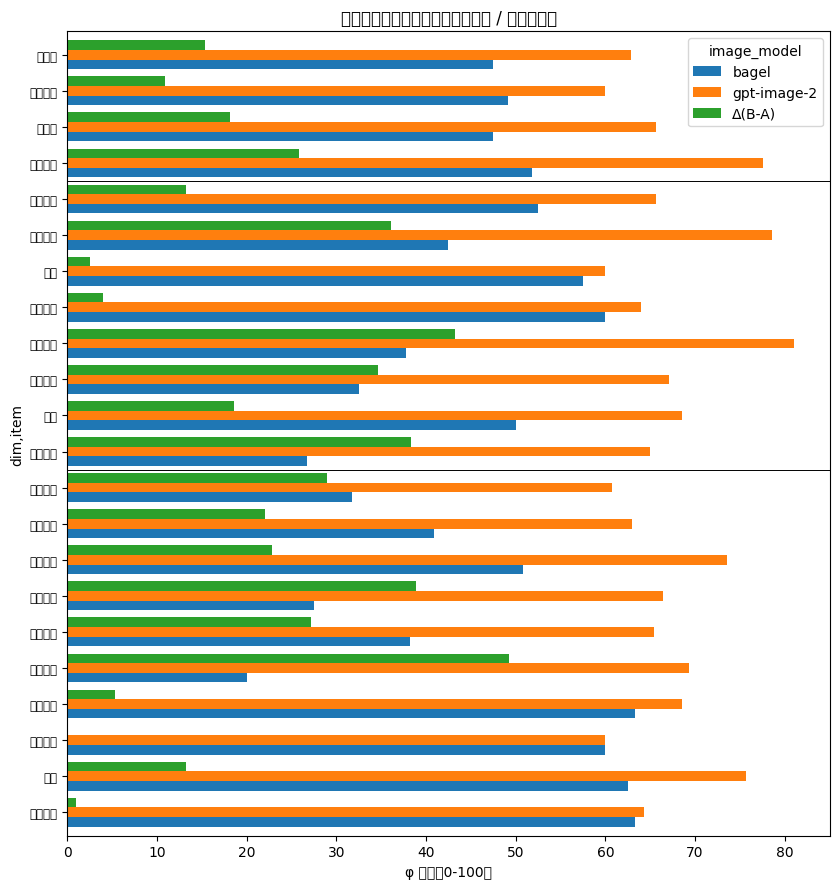

③ 零档频次（最常翻车的项）：


零档次数
image_model 中文        
bagel       动作交互    16
            状态情境    14
            形态结构    13
            空间关系    12
            主体在场    11
            文字符号    10
            颜色材质     8
gpt-image-2 空间关系     7
bagel       场景环境     7
            细节丰富     7
            数量尺度     5
            分辨率      5
            自然度      5
            物理逻辑     4
            材质质感     3

④ 难度剖面（三线分 × 题目层级）：


n  align  quality  aesthetic
image_model level                               
bagel       L1      2   42.2     47.1       60.0
            L2      9   31.7     51.4       64.4
            L3     13   34.3     49.1       61.0
gpt-image-2 L1      3   73.9     67.6       73.3
            L2     11   71.4     67.3       70.3
            L3     14   64.3     66.0       66.7

In [4]:
# ---- 消融③ 图源 bagel vs gpt-image-2 ----
import numpy as np

JUDGE_FOCUS = None   # None = 全判官合并；或 'openrouter/openai/gpt-5.6-sol' 等
COND_FOCUS = None    # None = 两条件合并；或 'v6.0-V5'

d2 = df if JUDGE_FOCUS is None else df[df['judge_model'] == JUDGE_FOCUS]
d2 = d2 if COND_FOCUS is None else d2[d2['schema'] == COND_FOCUS]
sel = [r for r in rows if (JUDGE_FOCUS in (None, r['judge_model']))
       and (COND_FOCUS in (None, r['schema']))]
print(f'聚焦样本 {len(d2)} 行（judge={JUDGE_FOCUS or "全部"}, cond={COND_FOCUS or "全部"}）')

print('① 图源总览：')
display(d2.groupby('image_model')
          .agg(n=('qid', 'size'), align=('alignment_score', 'mean'),
               quality=('quality_score', 'mean'), aesthetic=('aesthetic_score', 'mean'))
          .round(1))

it = pd.DataFrame([
    {'qid': r['qid'], 'image_model': r['image_model'], 'dim': d, 'item': k, 'phi': PHI[v]}
    for r in sel for d, (sk, _) in RK.items()
    for k, v in r[sk].items() if v in (0, 1, 2)])
detail = it.pivot_table(index=['dim', 'item'], columns='image_model', values='phi').round(1)
if len(detail.columns) == 2:
    detail['Δ(B-A)'] = (detail.iloc[:, 1] - detail.iloc[:, 0]).round(1)
detail_zh = detail.copy()
detail_zh.index = detail_zh.index.map(_zh)
print('② 明细项得分（φ 均值 0-100）：')
display(detail_zh)

ax = detail.plot(kind='barh', figsize=(8.5, 9), width=0.8)
ax.set_yticklabels([ITEM_ZH.get(k, k) for _, k in detail.index], fontsize=8.5)
ax.set_xlabel('φ 均值（0-100）')
ax.set_title('明细项得分：图源对比（{} / {}）'.format(
    (JUDGE_FOCUS or '判官合并').split('/')[-1], COND_FOCUS or '条件合并'))
dims = detail.index.get_level_values(0)
n_a = (dims == 'alignment').sum()
ax.axhline(n_a - 0.5, color='k', lw=0.7)
ax.axhline(n_a + (dims == 'quality').sum() - 0.5, color='k', lw=0.7)
plt.tight_layout(); plt.show()

z = (it[it['phi'] == 0].groupby(['image_model', 'item']).size()
      .rename('零档次数').reset_index())
z['中文'] = z['item'].map(lambda k: ITEM_ZH.get(k, k))
print('③ 零档频次（最常翻车的项）：')
display(z.sort_values('零档次数', ascending=False).head(15)
          .set_index(['image_model', '中文'])[['零档次数']])

print('④ 难度剖面（三线分 × 题目层级）：')
display(d2.groupby(['image_model', 'level'])
          .agg(n=('qid', 'size'), align=('alignment_score', 'mean'),
               quality=('quality_score', 'mean'), aesthetic=('aesthetic_score', 'mean'))
          .round(1))

AXES = ['subject_presence', 'form_structure', 'color_material', 'quantity_scale',
        'spatial_relation', 'text_symbol', 'action_interaction', 'state_context',
        'scene_environment', 'style']
HEAT_C = COND_FOCUS or 'v6.0-V5'
_cands = [JUDGE_FOCUS] if JUDGE_FOCUS else sorted({r['judge_model'] for r in rows})
HEAT_J = next((j for j in _cands
               if any(r['judge_model'] == j and r['schema'] == HEAT_C for r in rows)),
              _cands[0])
sub = sorted([r for r in sel if r['judge_model'] == HEAT_J and r['schema'] == HEAT_C],
             key=lambda r: r['qid'])
srcs = sorted({r['image_model'] for r in sub})
if sub:
    print(f'⑤ 逐题热力表（对齐十轴；{HEAT_J.split("/")[-1]} / {HEAT_C}）：')
    fig, axs = plt.subplots(1, len(srcs), squeeze=False,
                            figsize=(1.7 * len(AXES), 0.55 * len(sub) + 1.8))
    for ax, src in zip(axs[0], srcs):
        rs = [r for r in sub if r['image_model'] == src]
        mat = np.array([[np.nan if r['alignment_scores'][a] == 'N/A'
                         else r['alignment_scores'][a] for a in AXES] for r in rs])
        ax.imshow(mat, vmin=0, vmax=2, cmap='RdYlGn', aspect='auto')
        ax.set_xticks(range(len(AXES)))
        ax.set_xticklabels([ITEM_ZH[a] for a in AXES], rotation=60, fontsize=6.5)
        ax.set_yticks(range(len(rs)))
        ax.set_yticklabels([f"{r['qid']}·{r.get('level')}" for r in rs], fontsize=8)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                if not np.isnan(mat[i, j]):
                    ax.text(j, i, int(mat[i, j]), ha='center', va='center', fontsize=7)
        ax.set_title(f"{src}", fontsize=9)
    plt.tight_layout(); plt.show()

def show_reasons(qid, judge=None, cond=None, image_model=None):
    for r in rows:
        if r['qid'] != qid:
            continue
        if judge and r['judge_model'] != judge:
            continue
        if cond and r['schema'] != cond:
            continue
        if image_model and r['image_model'] != image_model:
            continue
        print(f"== {r['qid']} {r['schema']} | {r['judge_model']} | {r['image_model']} "
              f"| align={r['alignment_score']} qual={r['quality_score']} aes={r['aesthetic_score']}")
        for _, rk in RK.values():
            for k, v in r[rk].items():
                print(f"  [{ITEM_ZH.get(k, k)}] {v}")

# show_reasons('60002', image_model='bagel')

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


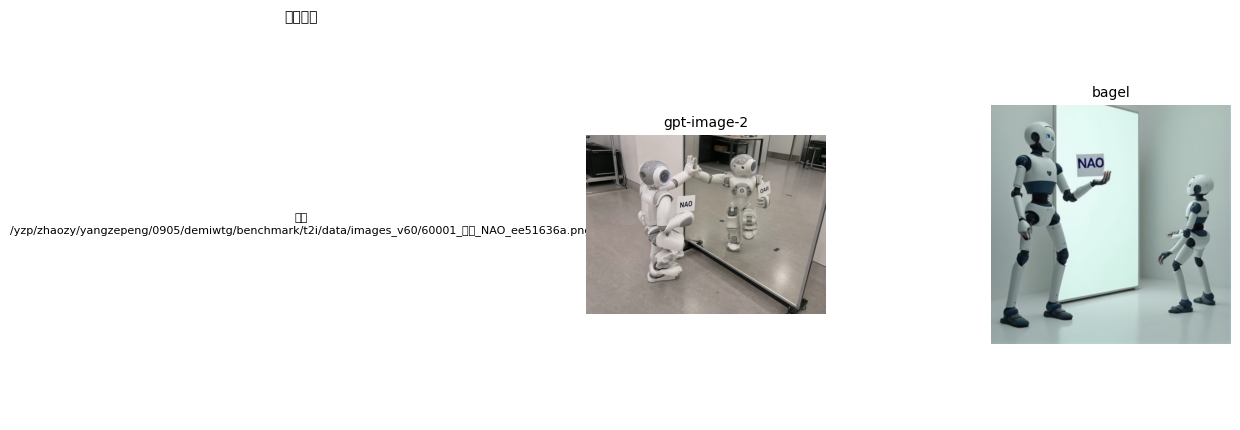

bagel·V2 gpt-image-2·V2
对齐 主体在场        0              1
   动作交互        0              0
   场景环境        1              1
   形态结构        1              0
   数量尺度        0              0
   文字符号        2              2
   状态情境        1              1
   空间关系        0              0
   颜色材质        1              1
   风格          0              1
美感 光影氛围        1              1
   情绪传达      N/A            N/A
   构图          1              1
   色彩和谐        1              1
质量 伪影          1              1
   分辨率         1              1
   材质质感        1              1
   物理逻辑        0              1
   细节丰富        1              1
   自然度         1              1
   解剖保真      N/A            N/A
   边缘清晰        1              1

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


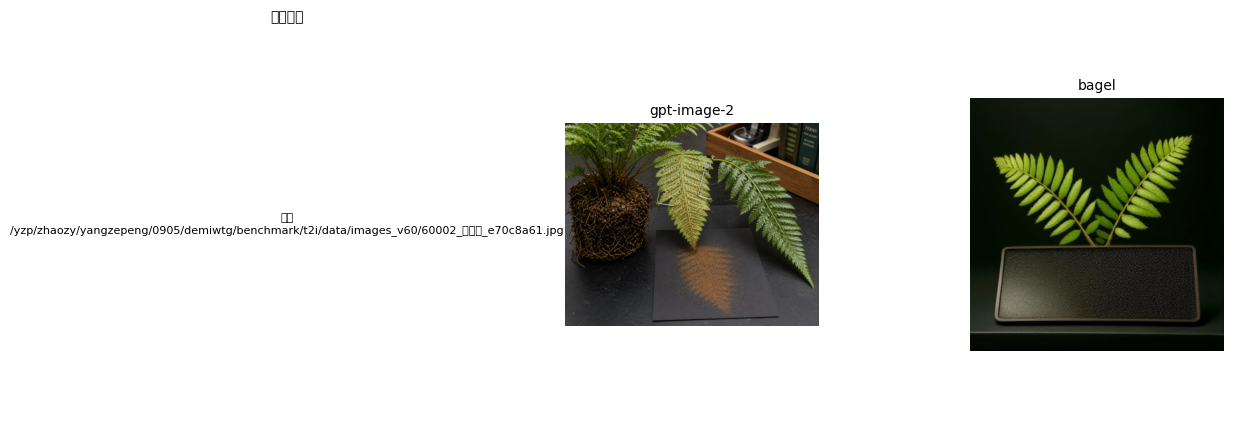

bagel·V2 gpt-image-2·V2
对齐 主体在场        0              1
   动作交互        0              2
   场景环境        0              1
   形态结构        0              2
   数量尺度        1              1
   文字符号      N/A            N/A
   状态情境        0              1
   空间关系        0              2
   颜色材质        1              2
   风格        N/A            N/A
美感 光影氛围        1              1
   情绪传达      N/A            N/A
   构图          1              2
   色彩和谐        1              2
质量 伪影          1              1
   分辨率         1              2
   材质质感        1              2
   物理逻辑        1              1
   细节丰富        0              2
   自然度         1              1
   解剖保真      N/A            N/A
   边缘清晰        1              2

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


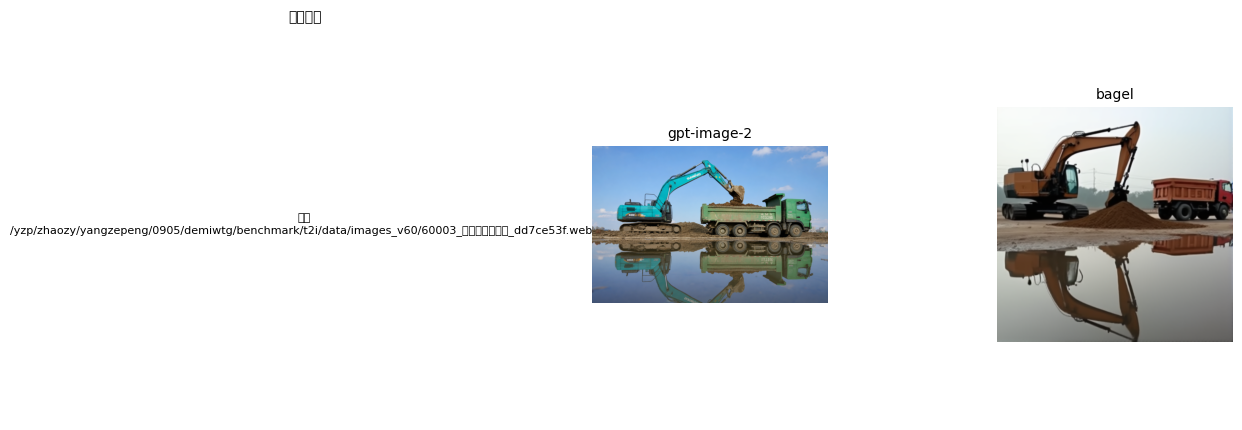

bagel·V2 gpt-image-2·V2
对齐 主体在场        0              1
   动作交互        0              1
   场景环境        1              1
   形态结构        1              1
   数量尺度        1              1
   文字符号        0              2
   状态情境        0              1
   空间关系        0              0
   颜色材质        0              1
   风格          1              1
美感 光影氛围        1              1
   情绪传达      N/A            N/A
   构图          1              1
   色彩和谐        1              1
质量 伪影          1              1
   分辨率         0              1
   材质质感        1              1
   物理逻辑        1              1
   细节丰富        1              1
   自然度         0              1
   解剖保真      N/A            N/A
   边缘清晰        1              1

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


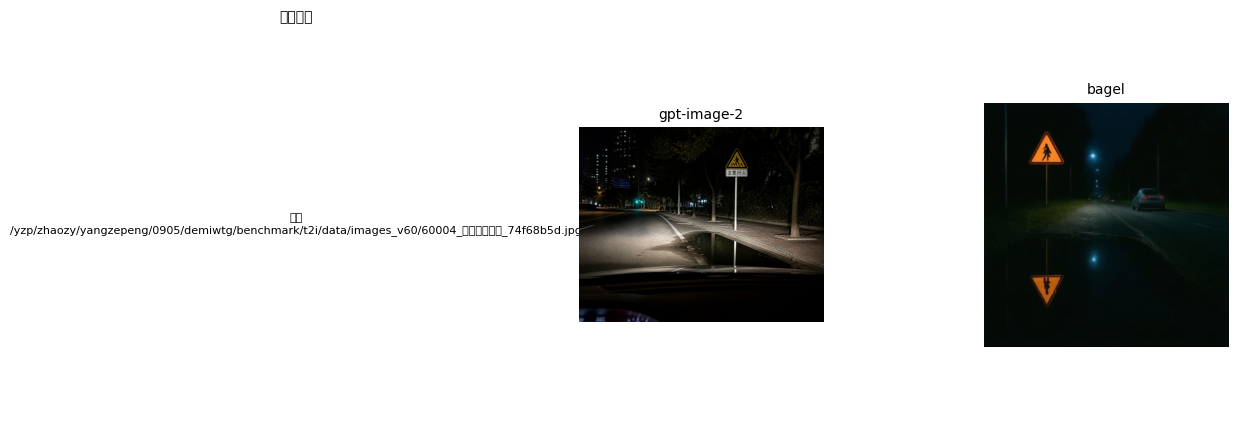

bagel·V2 gpt-image-2·V2
对齐 主体在场        1              1
   动作交互        1              1
   场景环境        1              1
   形态结构        1              2
   数量尺度        1              2
   文字符号        0              2
   状态情境        1              2
   空间关系        1              0
   颜色材质        0              2
   风格        N/A            N/A
美感 光影氛围        2              2
   情绪传达        1            N/A
   构图          2              1
   色彩和谐        2              1
质量 伪影          1              1
   分辨率         1              1
   材质质感        1              2
   物理逻辑        1              1
   细节丰富        1              2
   自然度         1              1
   解剖保真      N/A            N/A
   边缘清晰        1              2

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


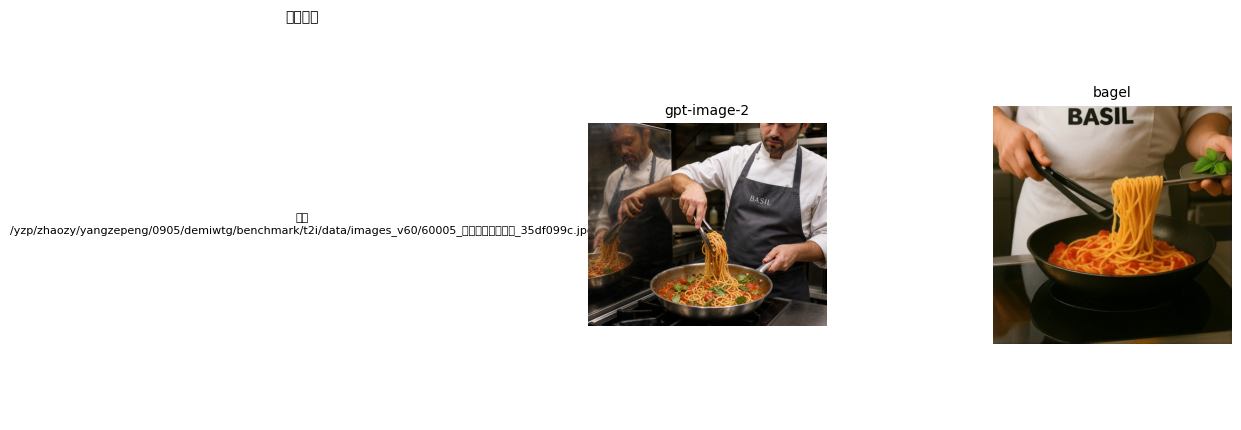

bagel·V2  gpt-image-2·V2
对齐 主体在场        0               1
   动作交互        0               1
   场景环境        1               1
   形态结构        0               0
   数量尺度        1               1
   文字符号        2               2
   状态情境        1               1
   空间关系        1               0
   颜色材质        1               0
   风格          1               1
美感 光影氛围        1               1
   情绪传达      N/A               1
   构图          1               1
   色彩和谐        1               1
质量 伪影          1               1
   分辨率         1               1
   材质质感        1               2
   物理逻辑        1               1
   细节丰富        1               2
   自然度         1               1
   解剖保真        1               1
   边缘清晰        1               1

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


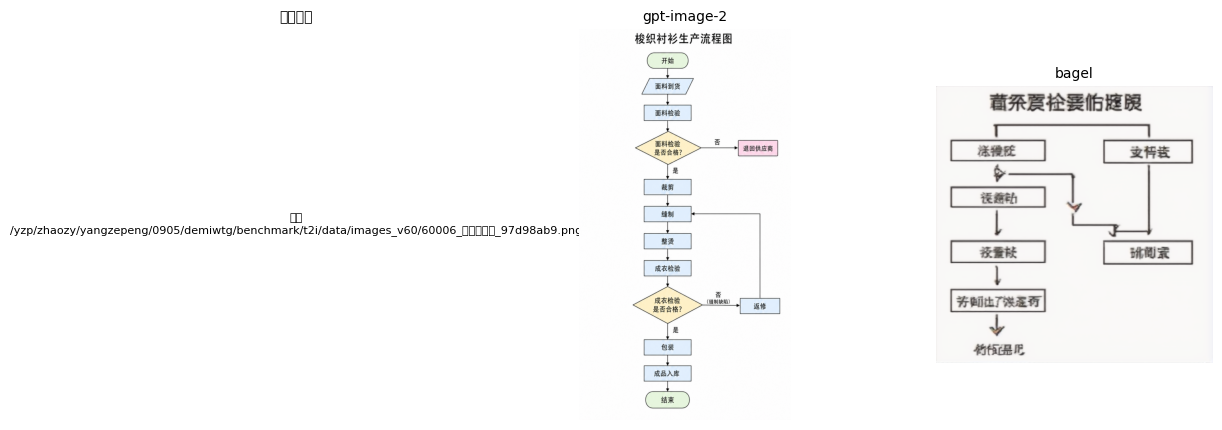

bagel·V2 gpt-image-2·V2
对齐 主体在场        1              1
   动作交互        0              2
   场景环境      N/A            N/A
   形态结构        0              2
   数量尺度        0              2
   文字符号        0              2
   状态情境        0              1
   空间关系        0              2
   颜色材质      N/A            N/A
   风格        N/A            N/A
美感 光影氛围        1              1
   情绪传达      N/A            N/A
   构图          0              1
   色彩和谐        1              1
质量 伪影          1              1
   分辨率         0              1
   材质质感      N/A            N/A
   物理逻辑      N/A            N/A
   细节丰富        0              1
   自然度         1              1
   解剖保真      N/A            N/A
   边缘清晰        0              1

findfont: Font family 'Noto Sans CJK SC' not found.


[60007] level=L3  题面：一张菌物阶段对照的近距离记录照片：同一批鸡腿菇（毛头鬼伞，Coprinus comatus）恰好两株，左边是适食的幼嫩未开伞期，右边是过熟后刚进入早期自溶期，并抓拍右株第一滴自溶液正在离开菌盖的瞬间。两株都沿菌柄中轴纵向剖成两半，各自一半以剖面朝向镜头、另一半以外表面朝向镜头；两组按阶段从左到右竖直固定，菌盖朝上且静止。采用正面略俯视的微距取景，让两株的菌盖外表、菌褶、菌柄纵剖面及空中液滴同时入画。
出题思路（V5 注入）：同一批鸡腿菇（前提）+ 恰好两株（前提）+ 左幼嫩右过熟的顺序（前提）→ 两株属于同一物种的连续发育阶段对照（组合）
左株处于适食的幼嫩未开伞期（前提）→ 尚未进入成熟散孢阶段（知识）→ 黑色孢子尚未大量积聚在菌褶表面（知识）→ [结论] 左株朝向镜头的菌褶呈白色
鸡腿菇幼嫩未开伞期（前提）→ 毛头鬼伞幼嫩菌盖保持细长卵形至圆柱形（知识）→ 菌盖表皮裂成毛状或鳞片状饰片（知识）→ [结论] 左株外表面朝向镜头的菌盖具有明显蓬松鳞片
两株均沿菌柄中轴纵剖（前提）+ 毛头鬼伞菌柄内部具有轴向空腔（知识）→ 纵剖面会贯穿并暴露该空腔（知识）→ [结论] 左株朝向镜头的菌柄剖面显示恰好一个纵向中央空腔
两株均沿菌柄中轴纵剖（前提）+ 毛头鬼伞菌柄内部具有轴向空腔（知识）→ 纵剖面会贯穿并暴露该空腔（知识）→ [结论] 右株朝向镜头的菌柄剖面显示恰好一个纵向中央空腔
右株处于过熟后的早期自溶期（前提）→ 已进入孢子成熟阶段（知识）→ 成熟孢子为黑色并大量附着于菌褶（知识）→ [结论] 右株朝向镜头的菌褶呈黑色
左株白色菌褶（知识节点）+ 右株黑色菌褶（知识节点）+ 左幼嫩右过熟的阶段排序（前提）→ 发育过程中菌褶随孢子成熟而显著变暗（知识）→ [结论] 右株菌褶明显深于左株菌褶
右株处于早期自溶期（前提）→ 毛头鬼伞自溶从菌盖下缘开始并逐渐向上推进（知识）→ 早期仅下缘组织先发生液化（知识）→ [结论] 右株菌盖下缘形成黑色湿润的液化带
右株处于早期自溶期（前提）→ 自溶尚未推进到整个菌盖（知识）→ 菌盖上部仍保留原有组织（知识）→ [结论] 右株菌盖顶部仍保留白色蓬松鳞片
右株过熟（前提）→ 孢子已经成熟（知识）→ 黑色孢子积聚使菌褶变黑（知识）→ 活跃自溶分解含黑色孢子的菌褶与菌盖组织（知识）→ 组织转化为带黑

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


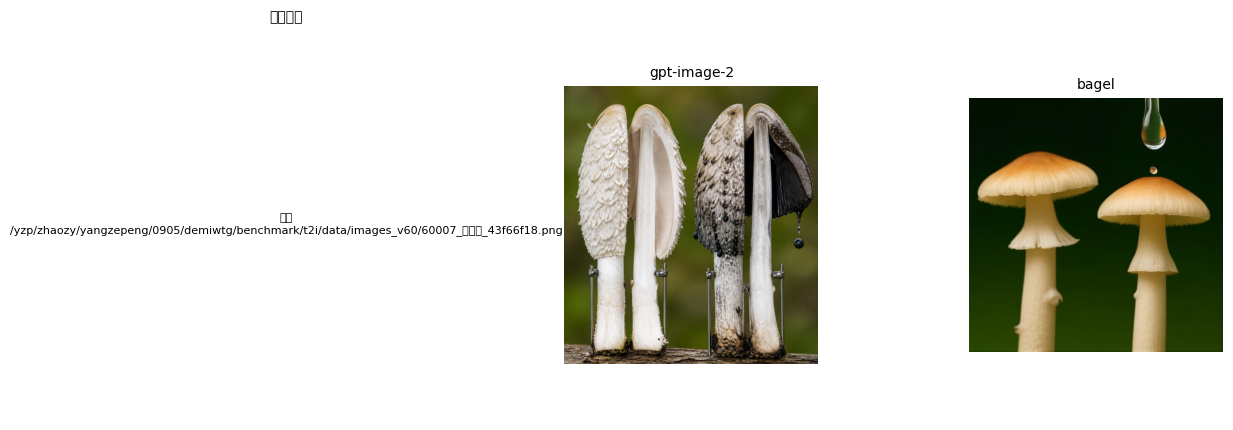

bagel·V2 gpt-image-2·V2
对齐 主体在场        0              2
   动作交互        0              2
   场景环境        1              1
   形态结构        0              0
   数量尺度        2              2
   文字符号      N/A            N/A
   状态情境        0              0
   空间关系        1              2
   颜色材质        0              2
   风格          1              2
美感 光影氛围        1              2
   情绪传达      N/A            N/A
   构图          1              2
   色彩和谐        1              2
质量 伪影          1              1
   分辨率         1              2
   材质质感        0              2
   物理逻辑        1              1
   细节丰富        0              2
   自然度         0              1
   解剖保真      N/A            N/A
   边缘清晰        1              2

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


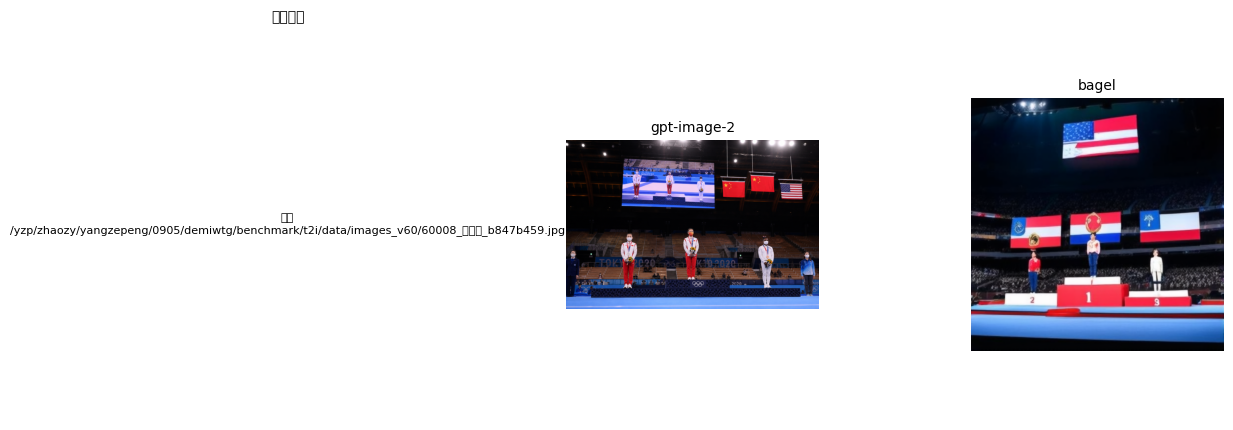

bagel·V2  gpt-image-2·V2
对齐 主体在场         0               2
   动作交互         0               1
   场景环境         0               2
   形态结构         0               1
   数量尺度         1               2
   文字符号         0               2
   状态情境         0               2
   空间关系         0               2
   颜色材质         0               2
   风格           0               2
美感 光影氛围         1               1
   情绪传达         1               1
   构图           1               2
   色彩和谐         1               1
质量 伪影           0               1
   分辨率          0               1
   材质质感         0               1
   物理逻辑         1               1
   细节丰富         0               2
   自然度          0               2
   解剖保真         1               1
   边缘清晰         0               1

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


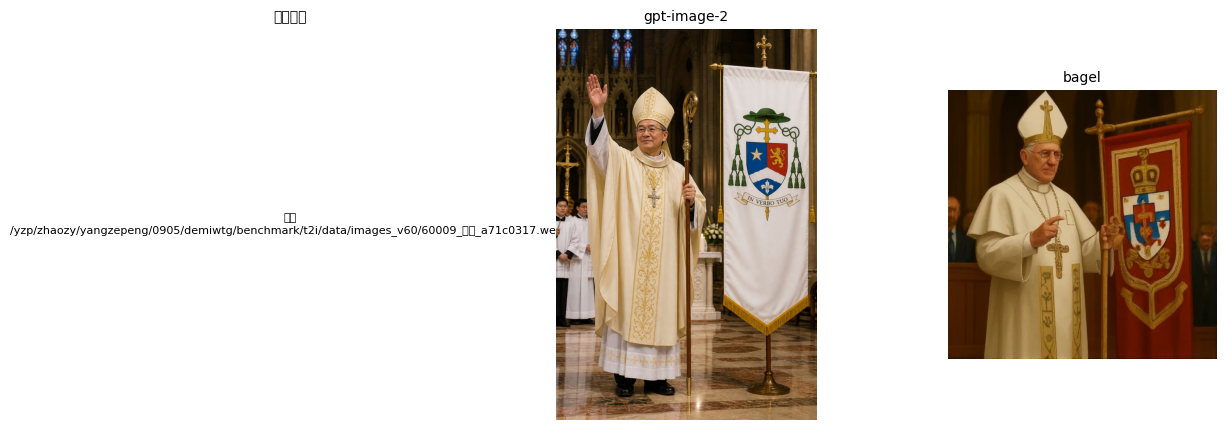

bagel·V2 gpt-image-2·V2
对齐 主体在场        0              1
   动作交互        0              2
   场景环境        0              2
   形态结构        0              2
   数量尺度        1              2
   文字符号        0              0
   状态情境        0              1
   空间关系        1              2
   颜色材质      N/A              1
   风格        N/A            N/A
美感 光影氛围        1              1
   情绪传达        1              1
   构图          1              2
   色彩和谐        1              1
质量 伪影          1              1
   分辨率         1              1
   材质质感        1              2
   物理逻辑        1              1
   细节丰富        1              2
   自然度         1              1
   解剖保真        1              1
   边缘清晰        1              2

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


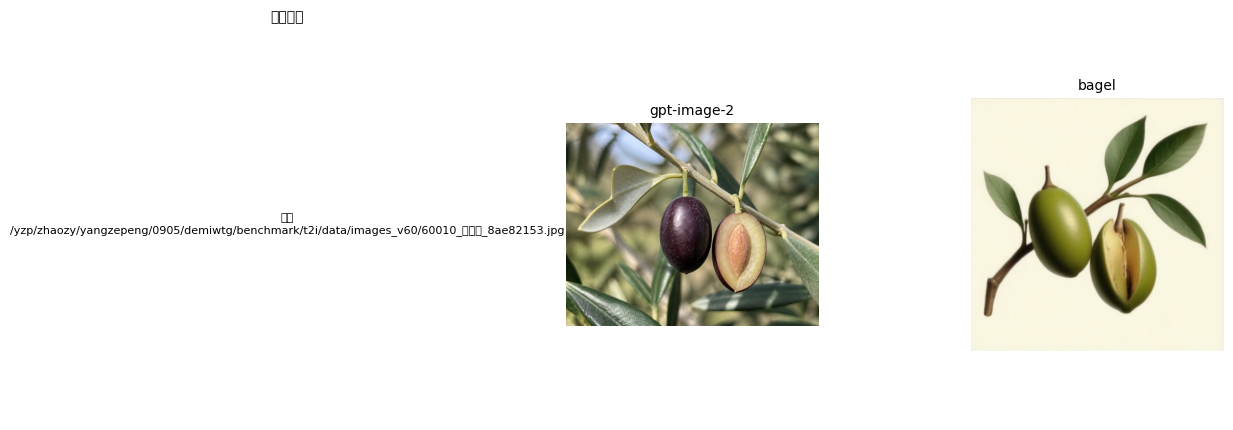

bagel·V2 gpt-image-2·V2
对齐 主体在场        1              2
   动作交互        1              1
   场景环境        1              1
   形态结构        0              2
   数量尺度        2              2
   文字符号      N/A            N/A
   状态情境        1              2
   空间关系        1              2
   颜色材质        0              1
   风格          1              1
美感 光影氛围        1              1
   情绪传达      N/A            N/A
   构图          1              2
   色彩和谐        1              1
质量 伪影          1              1
   分辨率         1              1
   材质质感        0              2
   物理逻辑        1              1
   细节丰富        0              2
   自然度         0              1
   解剖保真      N/A            N/A
   边缘清晰        1              1

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


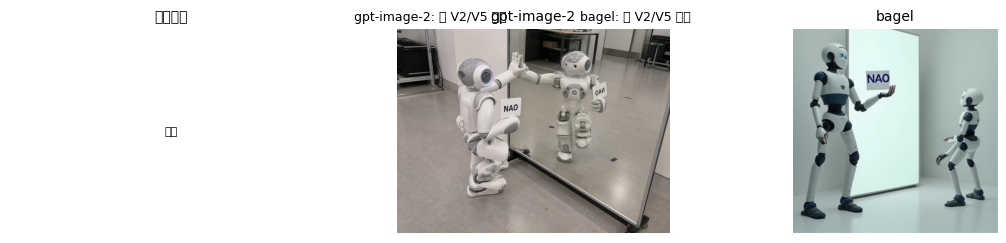

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


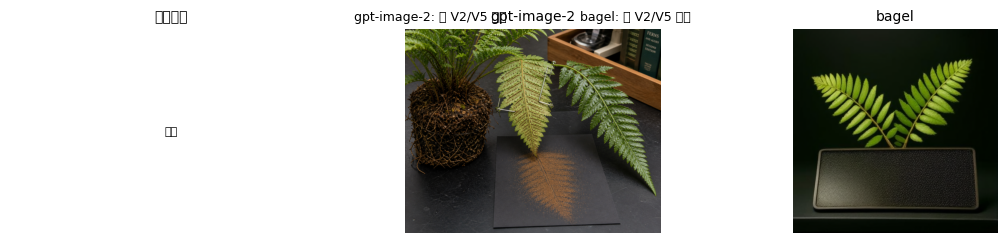

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


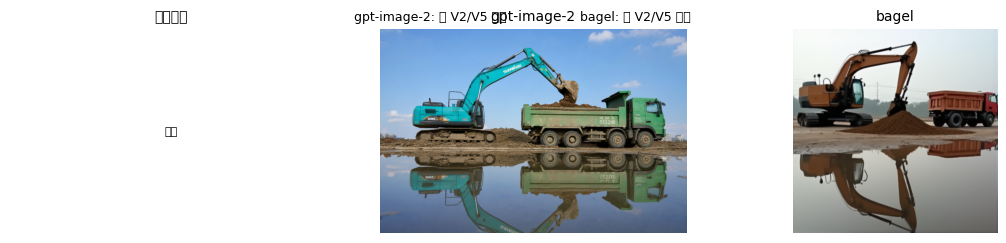

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


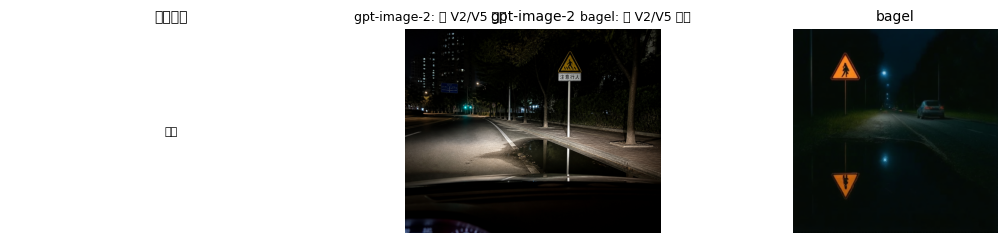

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


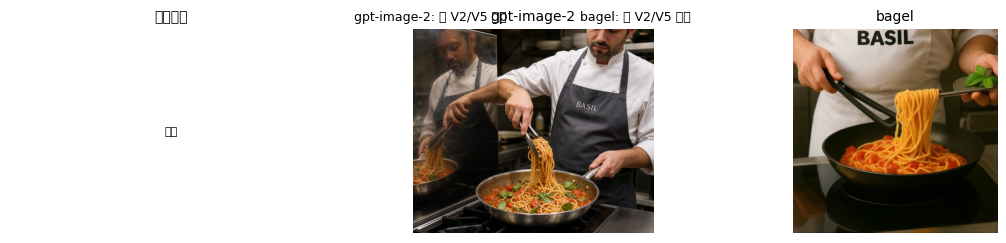

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


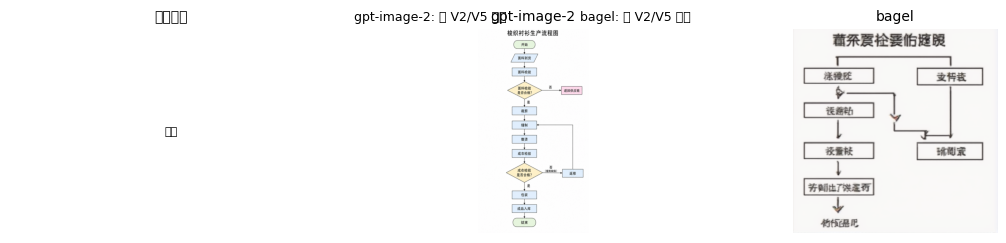

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


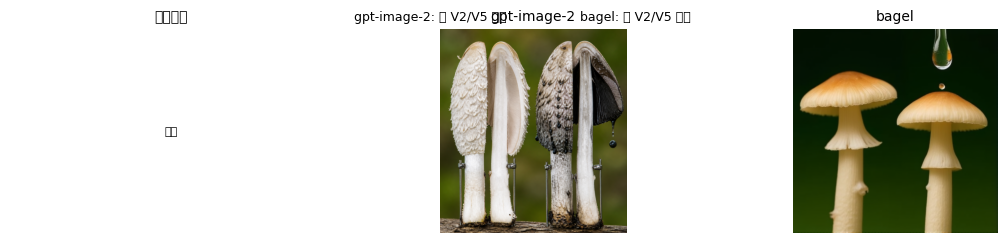

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


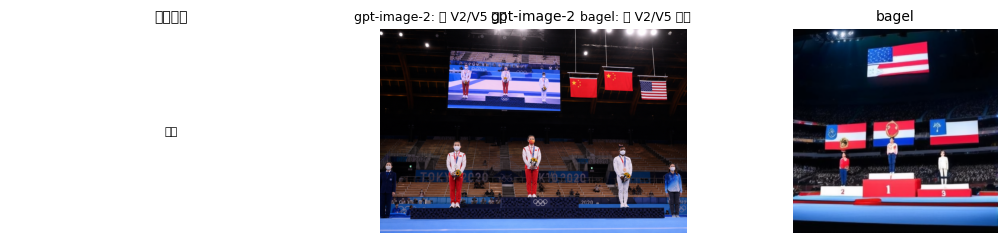

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


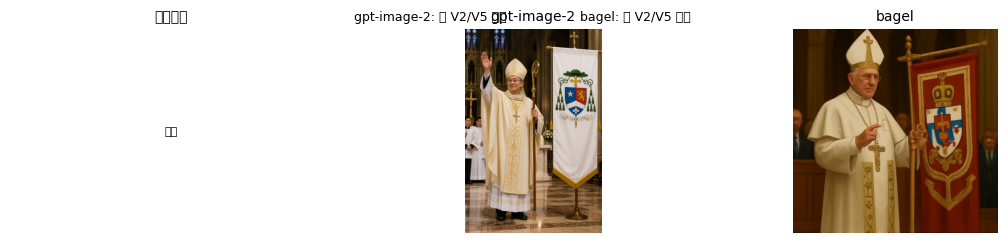

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


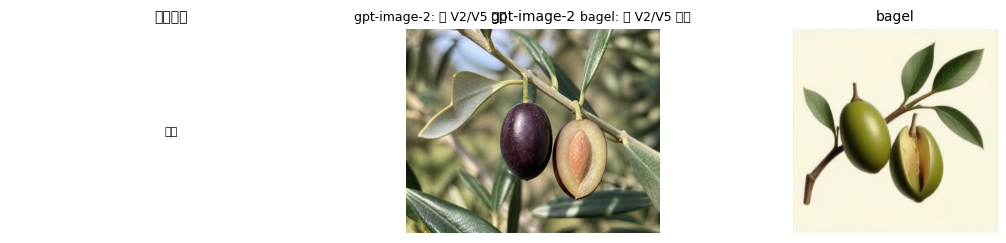

In [5]:
# ---- case 逐项对比：题面 + 图 + 全组合打分矩阵 + V2/V5 哑铃卡 ----
import numpy as np
from PIL import Image

SHOW = ['all']   # qid 列表；'all' = 全部
CASE_JUDGE = 'openrouter/openai/gpt-5.6-sol'   # 打分矩阵锁 sol；None = 全部判官
SHOW_VV = ['all']            # 哑铃卡 qid；'all' = 全部

AXES = ['subject_presence', 'form_structure', 'color_material', 'quantity_scale',
        'spatial_relation', 'text_symbol', 'action_interaction', 'state_context',
        'scene_environment', 'style']
QUAL = ['physical_logic', 'material_texture', 'detail_richness', 'artifacts',
        'resolution', 'edge_clarity', 'naturalness', 'anatomical_fidelity']
AES = ['composition', 'color_harmony', 'lighting_atmosphere', 'emotional_expression']
ITEMS_VV = [(d, k) for d, keys in (('alignment', AXES), ('quality', QUAL), ('aesthetics', AES))
            for k in keys]


def case_matrix(qid):
    case = [r for r in rows if r['qid'] == qid
            and (CASE_JUDGE in (None, r['judge_model']))]
    n_judge = len({r['judge_model'] for r in case})
    rec = {}
    for r in case:
        col = (f"{r['image_model']}·{r['schema'][-2:]}"
               + (f"·{r['judge_model'].split('/')[-1]}" if n_judge > 1 else ''))
        for d, (sk, _) in RK.items():
            for k, v in r[sk].items():
                rec.setdefault((d, k), {})[col] = v
    mat = pd.DataFrame.from_dict(rec, orient='index')
    mat.index = mat.index.map(_zh)
    return mat.sort_index()


def _dumbbell(ax, r2, r5, title):
    ys = np.arange(len(ITEMS_VV))[::-1]
    for (d, k), yy in zip(ITEMS_VV, ys):
        v2, v5 = r2[RK[d][0]][k], r5[RK[d][0]][k]
        if v2 == 'N/A' and v5 == 'N/A':
            ax.text(2.42, yy, 'N/A', fontsize=6.5, va='center', color='#999999')
            continue
        if v2 != 'N/A' and v5 != 'N/A':
            color = '#d62728' if v5 < v2 else ('#2ca02c' if v5 > v2 else '#bbbbbb')
            ax.plot([v2, v5], [yy, yy], color=color, lw=2.4, alpha=0.85, zorder=1,
                    solid_capstyle='round')
        if v2 != 'N/A':
            ax.scatter([v2], [yy], s=28, color='#7f7f7f', zorder=2)
        if v5 != 'N/A':
            ax.scatter([v5], [yy], s=34, color='#ff7f0e', zorder=3)
    ax.set_yticks(ys)
    ax.set_yticklabels([ITEM_ZH.get(k, k) for _, k in ITEMS_VV], fontsize=7.5)
    bounds = [len([1 for dd, _ in ITEMS_VV if dd == d]) for d in ('alignment', 'quality', 'aesthetics')]
    cum = len(ys)
    for (d, _), b in zip((('alignment', 0), ('quality', 0), ('aesthetics', 0)), bounds):
        cum -= b
        ax.axhline(cum + 0.5, color='k', lw=0.6)
        ax.text(2.42, cum - b / 2 + 0.5, d[:5], fontsize=7, rotation=90,
                va='center', color='#555555')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['0\n(0)', '1\n(60)', '2\n(100)'], fontsize=8)
    ax.set_xlim(-0.35, 2.75)
    ax.set_ylim(-0.8, len(ys) - 0.2)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='x', lw=0.4, alpha=0.4)


# ── A. 全组合打分矩阵（含图）──
for qid in (sorted(df['qid'].unique()) if SHOW == 'all' or 'all' in SHOW else SHOW):
    q = QS.get(qid, {})
    print('=' * 110)
    print(f"[{qid}] level={q.get('level')}  题面：{q.get('gen_prompt', '')}")
    if q.get('reasoning'):
        print(f"出题思路（V5 注入）：{q['reasoning']}")
    panels = [('参考样图', EVAL_DIR / q['_sample_image'] if q.get('_sample_image') else None)]
    panels += [(s, IMG_OF[s](qid)) for s in IMG_OF]
    fig, axs = plt.subplots(1, len(panels), figsize=(4.1 * len(panels), 4.4))
    for ax, (name, p) in zip(np.atleast_1d(axs), panels):
        if p and Path(p).exists():
            ax.imshow(Image.open(p))
        else:
            ax.text(0.5, 0.5, f'缺失\n{p}', ha='center', va='center', fontsize=8)
        ax.set_title(name, fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()
    display(case_matrix(qid))

# ── B. V2/V5 哑铃对照卡 ──
VV_JUDGE = 'openrouter/openai/gpt-5.6-sol'
for qid in (sorted({r['qid'] for r in rows}) if SHOW_VV == 'all' or 'all' in SHOW_VV else SHOW_VV):
    fig = plt.figure(figsize=(13.5, 11))
    gs = fig.add_gridspec(2, 3, height_ratios=[3.0, 8.2], hspace=0.22, wspace=0.12)
    panels = [('参考样图', EVAL_DIR / QS.get(qid, {}).get('_sample_image', '') if QS.get(qid, {}).get('_sample_image') else None)]
    panels += [(s, IMG_OF[s](qid)) for s in IMG_OF]
    for j, (name, p) in enumerate(panels):
        ax = fig.add_subplot(gs[0, j])
        if p and Path(p).exists():
            ax.imshow(Image.open(p))
        else:
            ax.text(0.5, 0.5, '缺失', ha='center', va='center', fontsize=8)
        ax.set_title(name, fontsize=10)
        ax.axis('off')
    sub = gs[1].subgridspec(1, 2, wspace=0.75)
    for j, src in enumerate(('gpt-image-2', 'bagel')):
        ax = fig.add_subplot(sub[0, j])
        r2 = next((r for r in rows if r['qid'] == qid and r['image_model'] == src
                   and r['judge_model'] == VV_JUDGE and r['schema'] == 'v6.0-V2'), None)
        r5 = next((r for r in rows if r['qid'] == qid and r['image_model'] == src
                   and r['judge_model'] == VV_JUDGE and r['schema'] == 'v6.0-V5'), None)
        if not (r2 and r5):
            ax.axis('off')
            ax.set_title(f'{src}: 无 V2/V5 配对', fontsize=9)
            continue
        _dumbbell(ax, r2, r5, f'{src}（灰=V2 橙=V5 红=严 绿=松）')
    plt.show()

① 结构指标 vs 门槛（六表门槛对照；复合标注按类别段计数）


,level,前提,门槛,结论,前提类,跳类型,跨度类,跨域,弱项,combo,r6,r8,r9,r10
qid,,,,,,,,,,,,,,
60001,L3,6,8,12,6,5,7,5,7,光学媒介,None,None,None,None
60002,L2,16,8,11,6,3,7,4,5,运动瞬间,None,None,None,None
60003,L3,19,8,14,7,6,14,7,6,接触交互,None,None,None,None
60004,L2,11,8,15,6,5,13,6,5,光学媒介,None,None,None,None
60005,L2,15,8,10,6,4,12,5,6,容纳承载,None,None,None,None
60006,L2,18,8,16,5,4,9,4,3,因果,None,None,None,None
60007,L3,16,8,15,8,5,11,3,5,多实例,None,None,None,None
60008,L2,13,8,14,6,5,10,4,5,文化语境,None,None,None,None
60009,L2,12,8,11,5,5,7,6,5,光影投影,None,None,None,None


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


/yzp/zhaozy/yangzepeng/0905/env-bagel/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/yzp/zhaozy/yangzepeng/0905/env-bagel/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21028 (\N{CJK UNIFIED IDEOGRAPH-5224}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/yzp/zhaozy/yangzepeng/0905/env-bagel/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


findfont: Font family 'Noto Sans CJK SC' not found.


[60001] level=L3  combo=光学媒介  weak_points=['镜面倒影', '精确计数', '接触交互链', '朝向左右', '手部细节', '长尾色材', '受力形变']
题面：具象写实的机器人实验室场景：一台保持出厂标准机身结构的 SoftBank Robotics NAO V6 与一名成人技术员正在双手交接一个柔软、易压缩的红色慢回弹泡沫立方体，画面定格在立方体重量刚转移到机器人双手的瞬间；机器人的解剖学右腕系有一条窄红色可拆卸校准带。机器人与一面洁净的落地平面镜约成四十五度，镜中机器人近似正面朝向画面；采用明亮漫射照明和略高的斜前方中广角取景，同时完整呈现机器人本体、技术员、立方体以及机器人全身镜像，并让本体与镜像的脸部、胸部、双手和右腕均清楚可见。
level_reason：前提密度：共11个原子前提——NAO V6、出厂标准机身、一台机器人、一名成人技术员、双手交接、重量刚转移完成、柔软易压缩的慢回弹泡沫材质、右腕红色校准带、机器人与平面镜约成45度、镜像近似正面、斜前方完整取景，覆盖变体/子类型、使用状态、数量/编组、阶段/时刻、环境场所、视角/暴露6类。蕴含深度：主体泡沫受力链最长6跳，镜像腕带方位链5跳；覆盖过程-因果、物理规律、功能-结构、关系（组合）、分类-辨识5种跳类型。知识长尾：NAO V6三指手、单一胸部圆形按钮、双眼环与无嘴面板均为机器人领域内公认但模型先验常缺的结构知识；长尾结论不少于6条。知识跨度：动用概念自身结构、状态与阶段、物理规律、环境交互、可组合关系5类；主域外注入材料与物质、知识与学科、人物与人体、行为动作、人造物体5个去重域。结论约束强度：正向结论12条，强约束10条，其中确切三指、单按钮、双眼环及镜中对应均属高精度；正确值×混淆值配对包括三指×五指、镜像左侧×错误右侧、单按钮×多个按钮。反刻板结论包括三指手、单胸钮、无嘴面板、镜像腕带换侧、镜像不得增件等不少于8条。长尾强约束交叉结论申报6条：本体三指、镜像三指、本体单胸钮、镜像单胸钮、本体双眼环、镜像双眼环。组合度：平面镜使本体结构、手—立方体接触、腕带方位与镜像同步，形成不少于7条关系约束。场景复杂度：实体密度、细节密度、交互链、过程时刻、视点剖示、纵深层次6类固定来源。弱点乘积结论至少3条：镜中三指为镜面倒影×精确计数/手部细节，镜中腕带

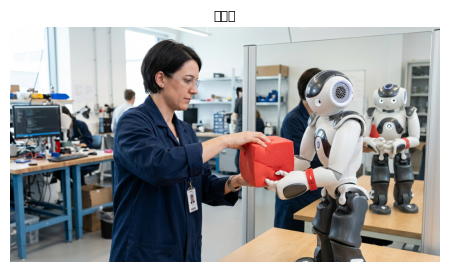

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


[60002] level=L2  combo=运动瞬间  weak_points=['精确计数', '长尾色材', '物理现象', '生态关系', '受力形变']
题面：雨后放晴的林下，一丛成年鳞毛蕨的叶面水分正在迅速蒸发，成熟孢子囊已到开裂临界；第一阵稳定而明显的干燥侧风正由左向右吹过。画面同时包含一枚叶背朝向镜头的成熟能育叶、一枚刚从根状茎抽出的幼叶，以及紧邻植株右侧下风处、绷在细枝间的完整园蛛圆网；一束侧向阳光横穿成熟叶与圆网之间。单幅写实微距照片，略低的斜侧视角，成熟叶背、叶柄基部、幼叶、两者之间的空气区域和圆网均完整可辨。
level_reason：前提密度：共12项场景设定性前提，包括成年植株、成熟能育叶、孢子囊处于开裂临界、雨后、正在迅速干燥、左向右稳定侧风、刚抽出的幼叶、下风侧圆网、圆网绷紧、侧向阳光、叶背视角、写实微距取景，覆盖年龄/生长阶段、阶段/时刻、环境场所、数量/编组、视角/暴露、使用状态6类。蕴含深度：主体散孢链最长7跳，覆盖过程-因果、物理规律、关系（组合）3种跳型。知识长尾：圆形离散孢子囊群、沿小羽片中脉两侧各成一列、肾形囊群盖、叶柄基部披针形鳞片均为领域内公认但模型先验常缺的结论，长尾结论4条。知识跨度：实际使用概念自身结构、状态与阶段、生物规律、物理规律、环境交互、可组合关系6类；知识域含植物及主域外的知识与学科、材料与物质、动物、自然景观，共4个跨域注入。结论约束强度：正向结论11条，其中孢子囊群形态、两列布局、囊群盖字形、孢子源点、飘移方向、圆网截留位置和受风形变构成8条连通牵扯组；强约束8条，高精度结论采用每枚清楚可见小羽片上中脉两侧各一列的确切两列布局。反刻板结论至少8条，并有2条钉住花果化与连续叶缘褐带混淆的负向结论。长尾强约束交叉结论4条：离散圆形囊群、两列布局、肾形囊群盖、棕褐色披针形鳞片。组合度：关系约束结论5条，覆盖孢子源点、风向输运、侧光显粒、圆网截留及圆网受力方向。场景复杂度：覆盖实体密度、细节密度、交互链、过程时刻、环境作用、多实例对比、动态要素7类。弱项命中精确计数、长尾色材、物理现象、生态关系、受力形变5类，达到互不相同弱项要求。
reasoning：
成年鳞毛蕨（前提）+ 成熟能育叶（前提）+ 叶背朝向镜头（前提）+ 写实微距取景（前提）→ 鳞毛蕨成熟能育叶的孢子囊群着生于叶背脉系附近（知识·概念自

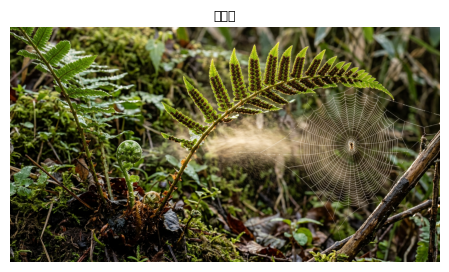

[60003] level=L3  combo=接触交互  weak_points=['精确计数', '文字字样', '接触交互链', '朝向左右', '部件数目', '物理现象']
题面：写实工程摄影：一台带完整原厂中英文双语品牌标识的山河智能标准履带式液压挖掘机，在市政沟槽工地进行侧向装车。挖掘机下车停稳在沟槽边的平整地面，履带纵向与沟槽平行；上车向左回转约四分之一圈，一辆自卸车平行停在挖掘机左侧。画面定格在装有本次挖取土方的铲斗越过车斗近侧上沿、进入卸料阶段的瞬间。采用左前方略高的三分之四视角，挖掘机整机、左侧驾驶室、配重后部、整套工作装置和自卸车车斗完整入画；动臂外侧与配重上的原厂标识区域朝向镜头且文字可辨。
level_reason：前提密度：共12个原子前提（标准履带式液压子类型、原厂双语标识、市政沟槽工地、侧向装车、下车停稳、履带平行沟槽、上车左转约四分之一圈、自卸车平行停在左侧、铲斗装有本次土方、铲斗越过近侧上沿、进入卸料阶段、左前略高且整机与标识区可见），覆盖变体/子类型、使用状态、阶段/时刻、环境场所、视角/暴露、事件语境、数量/编组7类。蕴含深度：主体卸料链最长6跳，覆盖过程-因果、功能-结构、物理规律、关系（组合）、规约-标准、量-守恒6种跳型。知识长尾：品牌双语标准字样、驾驶室侧位、配重与工作装置的相对布局、回转支承关系、三级工作装置连接等长尾结论不少于6条。知识跨度：动用概念自身结构、状态与阶段、规约与典故、物理规律、可组合关系、环境交互6类；知识域共8域，除主域交通工具外跨域注入7域，未使用禁用的材料与物质、知识与学科。结论约束强度：正向结论11条并由下车—回转上车—工作装置—铲斗—土流—车斗构成连通牵扯组，强约束9条；高精度结论4条，包括7字母SUNWARD、4汉字山河智能、恰好两条履带和三级顺序链，并有SUNWARD×SUNWORLD及山河智能×山河智慧两组正确值—混淆值配对；反刻板结论不少于8条。长尾强约束交叉结论申报7条：两项确切品牌字样、两条履带、驾驶室左前位、配重后置、三级工作装置顺序、上车与下车约四分之一圈关系。组合度：接触与承载关系结论4条以上，包括铲斗相对车斗、土流落点、车斗内新增堆积和工作装置连续连接。场景复杂度：实体密度、细节密度、交互链、过程时刻、视点剖示、动态要素、纵深层次共7类。弱点乘积结论至少2条：SUNW

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


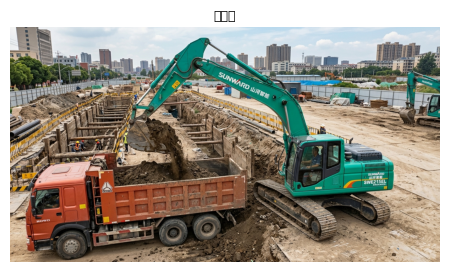

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


[60004] level=L2  combo=光学媒介  weak_points=['镜面倒影', '精确计数', '朝向左右', '光影一致性', '人体姿态']
题面：中国大陆一所小学放学时的城市支路，薄暮，细雨刚停。三名小学生正在校门前的无信号灯斑马线上横穿；一辆开启前灯的轿车沿无中央分隔的单向一车道驶来，在尚未到达路侧官方“注意行人标志”的位置开始制动，标志旁有一处平静浅水坑。单幅写实照片，采用略高的侧前视角，将轿车、标志正面、完整水坑倒影、斑马线、三名学生和校门按道路纵向纳入同一连续视野。
level_reason：前提密度：锁定中国大陆、小学路段、放学时刻、薄暮、雨后、平静浅水坑、无信号灯斑马线、三名学生正在横穿、单向一车道、轿车在标志前开始制动、前灯开启、略高侧前视和全体同框，共13项，覆盖事件/典故语境、阶段/时刻、环境场所、数量/编组、使用状态、视角/暴露6类。蕴含深度：主体水面倒影链最长5跳；覆盖规约-标准、分类-辨识、过程-因果、物理规律、关系（组合）5类。知识长尾：采用中国大陆警告标志的黄底黑边三角规制、注意行人图形与人行横道标志的区分、警告标志相对危险点的提前布设关系等领域内公认而模型易混淆的知识，长尾正向结论超过2条。知识跨度：概念自身结构、规约与典故、可组合关系、环境交互、物理规律、状态与阶段共6类；知识域包含主域节日与符号，并注入政治、法律与社会制度、交通工具、建筑与基础设施、人物与人体、自然景观、属性与状态6个主域外域，未使用禁用域。结论约束强度：正向结论14条并由实体—倒影同步、道路纵向次序和照明关系组成连通牵扯组；强约束至少8条，其中高精度结论包括实体标志恰为三边、恰有一个人形，以及倒影中对应数量均为一。反刻板结论至少8条。长尾强约束交叉结论申报5条：三边三角轮廓、向上顶角、黄底黑边层级、单个人形计数、倒影中的单一对应人形。组合度：实体标志与水坑倒影之间有轮廓、顶角方向、颜色层级、人形数量4项同步关系，另有标志—轿车—斑马线的方位关系及前灯照明关系，关系约束结论超过3条。场景复杂度：实体密度、过程时刻、环境作用、规约场景、纵深层次、光照时段、多人物编排共7类。视觉弱项命中镜面倒影、精确计数、朝向左右、光影一致性、人体姿态5类；含3条钉在交通标志高频混淆上的不得画结论。
reasoning：
中国大陆道路环境（前提）+ 官方安装

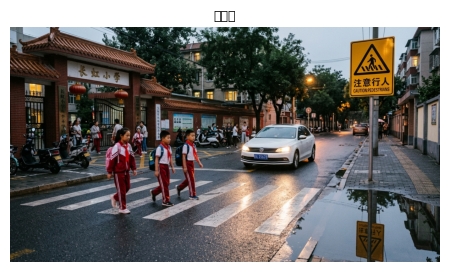

[60005] level=L2  combo=容纳承载  weak_points=['精确计数', '接触交互链', '手部细节', '物理现象', '长尾色材', '部件数目']
题面：单幅写实近景，餐厅厨房里正在完成番茄罗勒意大利面的收汁与装盘：保留的煮面水刚加入宽口炒锅，意大利面已在番茄酱中完成一轮大力翻拌，炉火刚刚关闭。主厨正用夹子把第一份面从锅中转入旁边仍基本空的浅白碗；助手同时在锅正上方徒手撕取同一株新鲜甜罗勒顶端的叶片，植株下段保留两个连续、完整可见的着叶节，朝向镜头的鲜切茎端也完整可见。采用近距离三分之二俯视角度，将锅底酱汁、夹持中的面束、碗内落点、两位厨师的手、罗勒的两个节及切口完整收入同一连续画面，以明亮中性厨房照明呈现。
level_reason：前提密度：共12个原子前提——餐厅厨房、煮面水刚加入、已完成一轮大力翻拌、炉火刚关闭、第一份面正在转移、宽口炒锅、相邻浅碗基本空、助手徒手撕叶、甜罗勒子类型、两个连续可见着叶节、鲜切端朝向镜头、近距离三分之二俯视与中性照明，覆盖阶段/时刻、使用状态、环境场所、数量/编组、变体/子类型、视角/暴露6类。蕴含深度：主体乳化链最长6跳，覆盖过程-因果、物理规律、分类-辨识、关系（组合）4种跳型。知识长尾：意面水淀粉辅助乳化，以及甜罗勒的对生、十字对生和近四棱茎均属领域内公认但模型先验常缺的知识；长尾结论5条。知识跨度：动用状态与阶段、物理规律、概念自身结构、生物规律、环境交互、可组合关系6类；知识域含食物、植物、行为动作、人造物体、材料与物质、知识与学科，主域外注入5域。结论约束强度：正向结论9条，沿罗勒植株—撕裂碎片—炒锅乳化酱—夹持面束—承载碗构成连通牵扯组；强约束5条，其中高精度结论为每节恰好两叶、相邻叶对轴线近直角、切面近四边形。反刻板结论7条，包括无清亮油环、面束有连续附着层、碗底无清水样液池、叶缘非刀切直线及三项罗勒结构。长尾强约束交叉结论3条，正是罗勒的精确叶数、近直角排列和近四边形切面。组合度：采用容纳承载，关系约束5条，覆盖酱汁对锅底、酱汁对面束、面束对碗、碎叶对锅以及锅中状态向碗中状态的传递。场景复杂度：命中实体密度、细节密度、交互链、过程时刻、动态要素、多人物编排6类。弱项：命中精确计数、接触交互链、手部细节、物理现象、长尾色材、部件数目6项；含钉在通用植物刻板印象上的不得画结论。


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


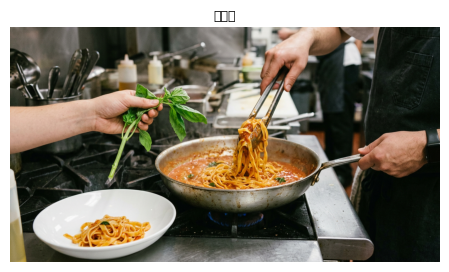

[60006] level=L2  combo=因果  weak_points=['文字字样', '朝向左右', '接触交互链']
题面：绘制一张中文信息图：现代乳品厂采用典型预均质工艺生产瓶装巴氏鲜奶，从槽车原奶进入工厂到冷藏成品，生产线正处于连续运行状态。全图采用自上而下的单一主线，只设置两个判定点，分别用于原奶验收和巴氏杀菌监控；验收不合格支线向左退出，合格支线向下继续，杀菌监控不达标支线回流，达标支线向下继续。使用圆角矩形表示起止、矩形表示工序、菱形表示判定、带箭头实线表示流向。白底平面矢量风格，正面平视，全图完整入画，所有中文短标签清晰可读。
level_reason：前提密度：共12项场景设定性前提（中文信息图、现代乳品厂、瓶装巴氏鲜奶、预均质路线、槽车原奶起点、冷藏成品终点、连续运行、自上而下单主线、两个指定判定点、验收左右分流、杀菌监控回流、正面完整可读），覆盖变体/子类型、环境场所、使用状态、数量/编组、视角/暴露5类。蕴含深度：主体冷链控制链最长6跳，覆盖规约-标准、过程-因果、功能-结构、关系（组合）4种跳型。知识长尾：净乳、预均质、杀菌监控回流、杀菌后快速冷却与冷藏终点等领域内公认但模型易遗漏的长尾结论不少于6条。知识跨度：动用概念自身结构、状态与阶段、可组合关系、规约与典故、生物规律5类；知识域包含主域文字与信息图形，并注入食物、行为动作、人造物体、时间数量与度量4个主域外域，未使用禁用域。结论约束强度：正向结论14条，形成同一有向流程的连通牵扯组；强约束不少于10条，其中确切短字样及其箭头邻接关系属于高精度结论；反刻板结论不少于8条。长尾强约束交叉结论共7条，包括“净乳”“均质”“巴氏杀菌”“达标？”“返工”“快速冷却”“冷藏成品”的确切字样、顺序或回流关系。组合度：采用因果主组合，验收分流、预处理顺序、杀菌监控、返工回流、冷却灌装冷藏之间共有10条以上关系约束。场景复杂度：覆盖实体密度、细节密度、交互链、规约场景、多实例对比5类固定来源。弱项命中文字字样、朝向左右、接触交互链3类；含2条钉在巴氏奶与常温灭菌奶混淆点上的不得画结论。
reasoning：
瓶装巴氏鲜奶、典型预均质路线（前提）+ 槽车原奶至冷藏成品（前提）+ 连续运行状态（前提）+ 自上而下单主线（前提）+ 生产工序与流程图节点的因果映射（组合）
生产流程图用有向连接表达工

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


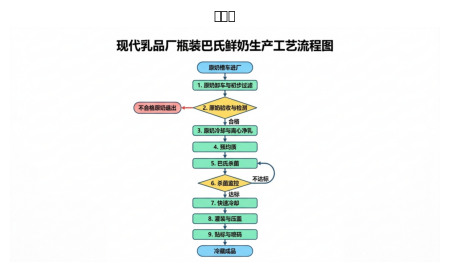

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


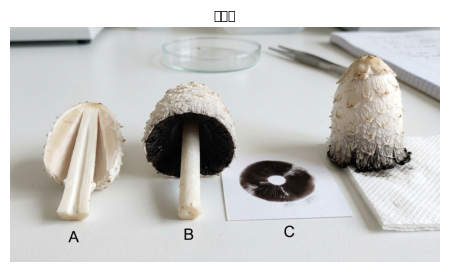

[60008] level=L2  combo=文化语境  weak_points=['精确计数', '朝向左右', '尺度并置', '长尾色材', '部件数目']
题面：东京2020奥运会女子平衡木决赛的正式颁奖仪式：奖牌颁发已经结束，正在奏冠军国歌并升起三面获奖国旗；管晨辰、唐茜靖和西蒙·拜尔斯是本场全部三名奖牌获得者，三人各自站在分配给自己的颁奖台上。采用颁奖台正前方的中近距离广角视角，三人全身与胸前区域、三座颁奖台和后方三面旗帜均完整入画，场馆照明明亮均匀，写实新闻摄影。
level_reason：前提密度：锁定东京2020届次、女子平衡木决赛、正式颁奖仪式、奖牌颁发完成、冠军国歌与升旗阶段、全部三名奖牌获得者及姓名、各站分配颁奖台、正前方视角、中近距离广角、人物与颁奖台及旗帜完整入画，共10项，覆盖时间/历史语境、事件/典故语境、阶段/时刻、数量/编组、使用状态、视角/暴露6类。蕴含深度：主体链由该场决赛出发，经正式成绩顺序、排名规则、奖牌映射、颁发完成后的佩戴状态、正面可见性落到人物与奖牌对应，最长5跳；覆盖规约-标准、文化-规制、序-时序、关系（组合）、分类-辨识5类。知识长尾：东京奥运会该单项前三名次序、三人的奖牌对应和双中国国旗的升旗排列均属领域内公认但模型先验易缺的赛事事实，长尾结论超过2条。知识跨度：动用规约与典故、可组合关系、状态与阶段、概念自身结构4类；知识域含主域人物与人体，并注入体育与游戏、组织机构与社会事件、民族、语言与文化、节日与符号4个主域外域。结论约束强度：15条正向结论形成名次—站位—奖牌—国旗的连通一致性组；强约束超过2条，高精度采用每人恰好一枚奖牌及两面中国国旗各自确切的五星纹样，未强贴无自然载体的文字。反刻板结论至少包括管晨辰居冠军位并佩金牌、唐茜靖佩银牌、拜尔斯居季军位并佩铜牌、升起两面中国国旗、冠军旗为中国国旗等5条。长尾强约束交叉结论至少包括三人的精确奖牌映射、三人的精确左右站位、双中国旗身份与五星纹样，共超过3条。组合度：人物分别与颁奖台、奖牌及对应国旗发生至少9条关系约束。场景复杂度：覆盖实体密度、细节密度、规约场景、多实例对比、纵深层次、多人物编排6类。弱项：命中精确计数、朝向左右、尺度并置、长尾色材、部件数目5项；含1条钉住名将默认夺金偏见的不得画结论。
reasoning：
东京2020届次（前提）+ 女

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


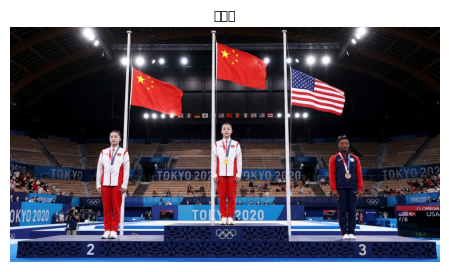

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


[60009] level=L2  combo=光影投影  weak_points=['精确计数', '接触交互链', '手部细节', '人体姿态', '光影一致性']
题面：一幅具象写实的单幅场景：罗马天主教拉丁礼主教祝圣礼中，祝圣祷词刚开始的时刻，以主礼主教为主体；现场仅有一位主礼主教、两位襄礼主教、一位候选司铎和两位执事。地点是主教座堂祭台前，时间为傍晚，一束直射阳光从画面左侧唯一的高窗射入，右侧浅色墙面完整入画。采用略高的侧面中广角视点，六人的全身、双手、候选人头顶区域及其墙上投影均在取景内。
level_reason：前提密度：锁定拉丁礼、主教祝圣礼、祝圣祷词阶段、三位祝圣主教编组、一位候选司铎、两位执事、主教座堂祭台前、傍晚、左侧单一高窗直射光、右侧浅色墙、略高侧面中广角及全身投影入画，共12项，覆盖变体/子类型、阶段/时刻、数量/编组、环境场所、视角/暴露5类。蕴含深度：仪式规约至执事双侧托书的主体链为5跳，左侧光源至右墙对应投影链为5跳；覆盖文化-规制、序-时序、功能-结构、物理规律、关系（组合）5种跳型。知识长尾：福音书在祝圣祷词期间覆于候选人头顶、两位执事共同托书、三位祝圣主教祷告时免冠、候选人尚未获授主教冠和牧杖均属领域内公认但模型先验常缺的礼仪知识，长尾结论不少于5项。知识跨度：动用规约与典故、状态与阶段、功能结构、物理规律、可组合关系5类；知识域包含宗教与信仰、人物与人体、行为动作、建筑与基础设施、时间数量与度量、知识与学科，满足至少2个主域外注入。结论约束强度：正向结论9项并由候选人—福音书—执事—祝圣主教的仪式空间关系及其对应投影组成连通牵扯组；强约束至少5项，其中精确高精度项以一个福音书、两位执事、三位祝圣主教的确切计数与位置关系替代字样。长尾强约束交叉结论共4项：单本福音书的位置、两位执事的双侧编排、三位主教的站姿与免冠状态。反刻板结论至少6项，包括头顶托举福音书、候选人跪姿、主教祷告时免冠、候选人尚无主教冠与牧杖、投影必须保留托书接触关系。组合度：光源、人物、福音书和墙面之间有4项以上投影方向、轮廓对应及接触连续性关系结论。场景复杂度：覆盖实体密度、细节密度、交互链、过程时刻、规约场景、光照时段、多人物编排、光影作用8类固定来源。弱项命中精确计数、接触交互链、手部细节、人体姿态、光影一致性5项；设置3项钉在礼仪阶段混淆点上的负向结

findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


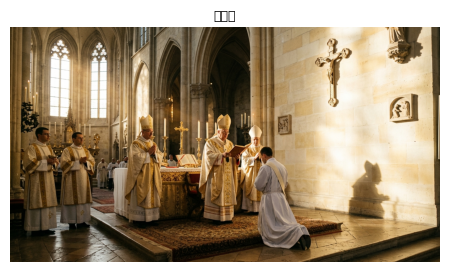

[60010] level=L1  combo=装配咬合  weak_points=['精确计数', '接触交互链', '手部细节', '长尾色材', '人体姿态']
题面：古代希腊时期，奥林匹亚圣域的男子赛跑颁奖刚开始。本场唯一的成年优胜者低下头，一名裁判正用双手把一根刚剪下、仍带叶的橄榄枝为他加冕。单幅写实画面，近距离侧前视角，两人上半身同框；加冕处居中，裁判双手、枝条两端、多个叶节以及若干翻转叶片的正反面均可辨。
level_reason：前提密度：锁定古代希腊时期、奥林匹亚圣域、男子赛跑、颁奖开始、唯一优胜者、成年、低头、一名裁判、双手操作、一根刚剪下且带叶的橄榄枝、近距离侧前视角及关键部位可见，共12项原子前提，覆盖时间/历史语境、环境场所、事件/典故语境、阶段/时刻、数量/编组、使用状态、视角/暴露7类。蕴含深度：主体考点最长为古代奥林匹亚语境→遵循古代竞技奖赏规制→优胜者获得科提诺斯→科提诺斯是橄榄枝冠→头冠须围合头顶→当前枝冠对准优胜者头顶，共5跳；覆盖文化-规制、功能-结构、物理规律、关系（组合）4种跳型。知识长尾：科提诺斯奖赏规制、橄榄叶对生结构和银灰色叶背均属领域内公认而模型先验易缺的知识；同时具有3条混淆点负向结论和多项视觉弱点。知识跨度：动用规约与典故、概念自身结构、生物规律、物理规律4类；以自然景观为主域，注入植物、历史与时代、民族语言与文化、体育与游戏、人物与人体、材料与物质6个域。结论约束强度：正向结论7条，均通过枝冠—枝端—叶节—叶面—头部构成连通牵扯组；强约束3条，其中高精度项为每个清楚叶节恰有两片对生叶，另有单枝连续围合及两端在同一接合处相遇；显著反刻板结论5条。长尾强约束交叉结论2条：科提诺斯的单枝围合接合结构、橄榄叶每节恰为两片对生。组合度：橄榄枝与头部、枝条两端、叶片与叶节、叶面正反方向形成5条关系约束。场景复杂度：命中实体密度、细节密度、交互链、过程时刻、规约场景5类。弱项命中精确计数、接触交互链、手部细节、长尾色材、人体姿态5类，达到L1全部门槛。
reasoning：
古代希腊时期（前提）+ 奥林匹亚圣域（前提）+ 男子赛跑颁奖（前提）→ 该场面遵循古代奥林匹亚竞技的奖赏规制（知识·规约与典故；域·历史与时代）→ 本场唯一优胜者是接受胜利冠饰者（知识·规约与典故；域·体育与游戏）→ 这种胜利冠饰是科提诺斯，即由橄榄枝

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


...

findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


findfont: Font family 'Noto Sans CJK SC' not found.


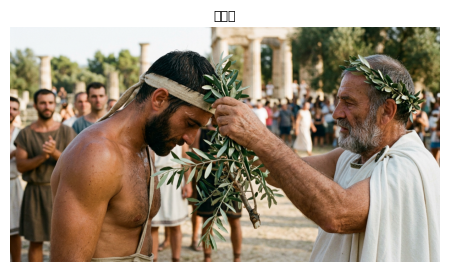

In [6]:
# ---- r10（新梯+弱点乘积批）· 题目明细与历批对照（自包含，可单独运行）----
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# cwd 自适应：仓库根或 benchmark/t2i/ 启动均可
# cwd 自适应：从 t2i/ 或 reviews/ 启动均可（2026-09-05 重组布局）
T2I = Path.cwd() if (Path.cwd() / 'bench200').exists() else Path.cwd().parent
EVAL_DIR_ = T2I / 'data'
ARCHIVE = T2I / 'archive' / 'v60_ladder'
V5LINE = T2I / 'archive' / 'v5_line'
V1BENCH = T2I / 'bench200'
R10_SYNTH = T2I / 'bench200' / 'provenance' / 'r10_synth'
assert EVAL_DIR_.exists() and ARCHIVE.exists(), f'路径解析失败（当前 {cwd}）'.format(cwd=Path.cwd())

R10_DIR = R10_SYNTH
R10_EVAL = ARCHIVE / 'eval_v60_r10'
R10_Q = {q['qid']: q for q in
         (json.loads(l) for l in (R10_DIR / 'questions_v60_gpt-5.6-sol.jsonl')
          .read_text(encoding='utf-8').splitlines() if l.strip())}

def _load(fp):
    fp = Path(fp)
    if not fp.exists():
        return {}
    return {r['qid']: r for r in
            (json.loads(l) for l in fp.read_text(encoding='utf-8').splitlines() if l.strip())
            if not r.get('fail')}

S10 = _load(EVAL_DIR_ / 'scores_r10_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')
S9 = _load(EVAL_DIR_ / 'scores_r9_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')
S8 = _load(EVAL_DIR_ / 'scores_r8_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')
S6 = _load(EVAL_DIR_ / 'scores_r6_v60_V2_gpt-5.6-sol_gemini-3.1-flash-image.jsonl')

GATE_PRE = {'L1': 6, 'L2': 8, 'L3': 8}

print('① 结构指标 vs 门槛（六表门槛对照；复合标注按类别段计数）')
rows = []
for qid, q in sorted(R10_Q.items()):
    rs = str(q.get('reasoning') or '')
    kinds = {d.split('；域·')[0] for d in re.findall(r'（知识·([^）]+)）', rs)}
    kdoms = q.get('knowledge_domains') or []
    main_dom = kdoms[0] if kdoms else None
    rows.append({'qid': qid, 'level': q.get('level'),
                 '前提': rs.count('（前提）'), '门槛': GATE_PRE.get(q.get('level')),
                 '结论': rs.count('[结论]'),
                 '前提类': len(set(q.get('premise_types') or [])),
                 '跳类型': len(set(q.get('hop_types') or [])),
                 '跨度类': len(kinds),
                 '跨域': len([d for d in kdoms[1:]]) if main_dom else 0,
                 '弱项': len(set(q.get('weak_points') or [])),
                 'combo': q.get('combo_type'),
                 'r6': (S6.get(qid) or {}).get('alignment_score'),
                 'r8': (S8.get(qid) or {}).get('alignment_score'),
                 'r9': (S9.get(qid) or {}).get('alignment_score'),
                 'r10': (S10.get(qid) or {}).get('alignment_score')})
display(pd.DataFrame(rows).set_index('qid'))

SHOW_R10 = ['all']   # qid 列表或 'all'

for qid in (sorted(R10_Q) if SHOW_R10 == 'all' or 'all' in SHOW_R10 else SHOW_R10):
    q = R10_Q.get(qid, {})
    print('=' * 110)
    print(f"[{qid}] level={q.get('level')}  combo={q.get('combo_type')}  "
          f"weak_points={q.get('weak_points')}")
    print(f"题面：{q.get('gen_prompt', '')}")
    print(f"level_reason：{q.get('level_reason', '')}")
    print(f"reasoning：\n{q.get('reasoning', '')}")
    p = R10_EVAL / 'imgs' / 'gemini-3.1-flash-image' / f'{qid}.png'
    s = S10.get(qid)
    if p.exists():
        fig, ax = plt.subplots(figsize=(4.6, 4.8))
        ax.imshow(Image.open(p))
        ax.set_title(f"gemini·r10\n对齐 {s['alignment_score']} | 质量 {s['quality_score']} | 美感 {s['aesthetic_score']}"
                     if s else '无判分', fontsize=9)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ── 明细打分项：22 项逐项档位（r10 + 历批同题对照）+ 非常档理由 ──
    if s:
        ITEM_ZH = {'subject_presence': '主体在场', 'form_structure': '形态结构',
                   'color_material': '颜色材质', 'quantity_scale': '数量尺度',
                   'spatial_relation': '空间关系', 'text_symbol': '文字符号',
                   'action_interaction': '动作交互', 'state_context': '状态情境',
                   'scene_environment': '场景环境', 'style': '风格',
                   'physical_logic': '物理逻辑', 'material_texture': '材质质感',
                   'detail_richness': '细节丰富', 'artifacts': '伪影', 'resolution': '分辨率',
                   'edge_clarity': '边缘清晰', 'naturalness': '自然度',
                   'anatomical_fidelity': '解剖保真', 'composition': '构图',
                   'color_harmony': '色彩和谐', 'lighting_atmosphere': '光影氛围',
                   'emotional_expression': '情绪传达'}
        DIM_ZH = {'alignment': '对齐', 'quality': '质量', 'aesthetics': '美感'}
        RK10 = {'alignment': ('alignment_scores', 'alignment_reasons'),
                'quality': ('quality_scores', 'quality_reasons'),
                'aesthetics': ('aesthetic_scores', 'aesthetic_reasons')}
        print('── 明细打分项（r10 / gpt-5.6-sol / V2；一行一项：档位＋理由全文）')
        for d, (sk, rk) in RK10.items():
            for k, v in s[sk].items():
                print(f"  [{DIM_ZH[d]}·{ITEM_ZH.get(k, k)}] {v}：{s[rk].get(k, '')}")